# Libraries

In [8]:
import pandas as pd
import re, shutil
from matplotlib.lines import Line2D
import os
import pickle
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from scipy.interpolate import griddata
import numpy as np
import matplotlib.ticker as ticker
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, mark_inset
from matplotlib.ticker import AutoMinorLocator
from scipy.interpolate import griddata
from scipy.interpolate import RectBivariateSpline
from matplotlib.patches import Patch
from scipy.interpolate import make_interp_spline
from scipy.interpolate import PchipInterpolator
from scipy.signal import savgol_filter
from scipy.optimize import curve_fit
from statsmodels.nonparametric.smoothers_lowess import lowess
from scipy.interpolate import UnivariateSpline

# Helper Function

In [9]:
METRICS = [
    'pdr',
    'total_packet_sent',
    'collision_failure',
    'avg_energy_consumption',
    'avg_latency_ms',
    'alive_nodes',
    'channel_busy_failure',
    'hidden_node_detected',
    'exposed_node_detected',
    'throughput_kbps',
    'throughput_bps',
    'collision_failure',
    'normalized_throughput',
    'total_backoffs'

]


def set_ieee_style(usetex=True, backend=None):
    """
    Apply rcParams and style sheet to mimic an IEEE pgfplots figure.
    
    Parameters
    ----------
    usetex : bool
        Use LaTeX for text rendering (requires a working LaTeX installation).
    backend : str or None
        Matplotlib backend. If 'pgf', the output can be saved as .pgf for
        direct inclusion in LaTeX documents (requires 'pgf' package).
    """
    plt.style.use('seaborn-v0_8-paper')  # clean base style

    rc = {
        # Typography (IEEE standard sizes)
        'font.family': 'serif',
        'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
        'font.size': 8,                # base font size (8pt for IEEE)
        'axes.labelsize': 8,
        'axes.titlesize': 8,
        'legend.fontsize': 7,
        'xtick.labelsize': 7,
        'ytick.labelsize': 7,

        'text.usetex': usetex,
        'text.latex.preamble': r'\usepackage{newtxtext,newtxmath}',  # Times math

        # Figure dimensions for single-column IEEE (3.5 in width)
        'figure.dpi': 300,
        'savefig.dpi': 600,
        'savefig.bbox': 'tight',
        'savefig.pad_inches': 0.02,

        # Axes: full box (pgfplots default)
        'axes.linewidth': 0.6,
        'axes.grid': False,
        'axes.spines.top': True,
        'axes.spines.right': True,

        # Grid appearance (minor y grid as in pgfplots)
        'grid.alpha': 0.3,
        'grid.linestyle': ':',
        'grid.linewidth': 0.4,

        # Ticks (inward, pgfplots style)
        'xtick.direction': 'in',
        'ytick.direction': 'in',
        'xtick.major.size': 3.5,
        'ytick.major.size': 3.5,
        'xtick.minor.size': 2.0,
        'ytick.minor.size': 2.0,
        'xtick.major.width': 0.6,
        'ytick.major.width': 0.6,
        'xtick.minor.width': 0.5,
        'ytick.minor.width': 0.5,
        'xtick.top': True,
        'ytick.right': True,

        # Legend: thin black border, no fill (pgfplots legend style)
        'legend.frameon': True,
        'legend.edgecolor': 'black',
        'legend.fancybox': False,
        'legend.framealpha': 1.0,
        'legend.facecolor': 'white',   # or 'none' if you prefer transparent

        # Lines and markers
        'lines.linewidth': 0.8,
        'lines.markersize': 4,
        'lines.markeredgewidth': 0.6,
        'hatch.linewidth': 0.5,
    }

    plt.rcParams.update(rc)

    # Optionally switch to PGF backend for direct .pgf output
    if backend == 'pgf':
        plt.switch_backend('pgf')
        plt.rcParams.update({
            'pgf.texsystem': 'pdflatex',
            'pgf.rcfonts': False,
        })


def apply_pgfplots_style(ax, xlim=None, ylim=None, y_pad=0.08):
    """
    Tune a matplotlib Axes to look like a pgfplots axis.
    
    Parameters
    ----------
    ax : matplotlib.axes.Axes
    xlim, ylim : tuple, optional
        Axis limits. If None, limits are taken from the data.
    y_pad : float
        Fractional padding for the y‑axis (mimics `enlarge y limits`).
    """
    # Minor ticks on both axes
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

    # Major tick parameters (already set globally, but ensure per-axis)
    ax.tick_params(which='both', direction='in', top=True, right=True)
    ax.tick_params(which='major', length=3.5, width=0.6)
    ax.tick_params(which='minor', length=2.0, width=0.5)

    # Grid: only y axis (typical for this kind of plot), minor grid lines optional
    ax.grid(axis='y', which='major', linestyle=':', linewidth=0.4, color='0.7')
    # Uncomment the next line to add minor y grid (very pgfplots-like)
    # ax.grid(axis='y', which='minor', linestyle=':', linewidth=0.3, color='0.85')

    # Adjust limits with automatic padding (like enlarge y limits)
    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is None:
        ymin, ymax = ax.get_ylim()
        pad = (ymax - ymin) * y_pad
        ax.set_ylim(ymin - pad, ymax + pad)
    else:
        ax.set_ylim(ylim)

    # Legend style (if legend exists, set border and no fill)
    legend = ax.get_legend()
    if legend is not None:
        legend.get_frame().set_linewidth(0.5)
        legend.get_frame().set_facecolor('none')  # transparent fill


def parse_n_l_from_trial(path):
    """
    Parse N and L from a trial folder name like:
    TRIAL - 1 - (22-06-2026) - Ideal_DirectUnslottedCSMA_N10_L10
    """

    # First try YAML file
    for f in os.listdir(path):
        if f.endswith(".yaml"):
            match = re.search(r'_N(\d+)_L(\d+)', f, re.IGNORECASE)
            if match:
                return int(match.group(1)), int(match.group(2))

    # Fallback: parse folder name
    folder_name = os.path.basename(path)

    match = re.search(r'_N(\d+)_L(\d+)', folder_name, re.IGNORECASE)
    if match:
        return int(match.group(1)), int(match.group(2))

    return None, None

def get_metric_from_trial(trial_path, metric_name):
    """
    Returns the aggregated metric for one trial.
    Assumes the trial folder contains subfolders 'Period-0', 'Period-1', ...
    For each round, load the pickle files and collect the metric.
    If metric_name is 'avg_energy_consumption', we compute it from the energy file.
    """
    periods = sorted([d for d in os.listdir(trial_path)
                      if os.path.isdir(os.path.join(trial_path, d)) and d.startswith("Period-")])

    # For energy consumption, we need to compute per period
    if metric_name == 'avg_energy_consumption':
        total_energy_per_period = []
        for period in periods:
            energy_file = os.path.join(trial_path, period, 'energy_consumption_results.pkl')
            if os.path.exists(energy_file):
                with open(energy_file, 'rb') as f:
                    energies = pickle.load(f)
                total = sum(v * 1e3 for v in energies.values())  # J to mJ?
                total_energy_per_period.append(total / len(energies))  # per-node average?
        if total_energy_per_period:
            return np.mean(total_energy_per_period)
        else:
            return np.nan

    # For all other metrics stored in metrics_results.pkl or transmission_results.pkl
    values = []
    for period in periods:
        # metrics
        metrics_file = os.path.join(trial_path, period, 'metrics_results.pkl')
        if os.path.exists(metrics_file):
            with open(metrics_file, 'rb') as f:
                data = pickle.load(f)
                if metric_name in data:
                    values.append(float(data[metric_name]))

        # transmission results
        trans_file = os.path.join(trial_path, period, 'transmission_results.pkl')
        if os.path.exists(trans_file):
            with open(trans_file, 'rb') as f:
                data = pickle.load(f)
                if metric_name in data:
                    values.append(float(data[metric_name]))

    if values:
        # The user's original aggregation: for PDR they average over rounds,
        # for alive_nodes they take the last round's value.
        # Here we just return the overall mean; adjust if needed.
        if metric_name == 'alive_nodes':
            return values[-1]  # last round only
        return np.mean(values)
    else:
        return np.nan

def collect_data(path):
    """
    Returns a dict: data[N][L] = list of metric_values (one per replication).
    """
    results = {}
    for trial_name in os.listdir(path):
        trial_path = os.path.join(path, trial_name)
        if not os.path.isdir(trial_path) or not trial_name.startswith("TRIAL"):
            continue

        N, L = parse_n_l_from_trial(trial_path)
        if N is None or L is None:
            continue

        # Get all metrics for this trial
        metrics_vals = {}
        for m in METRICS:
            val = get_metric_from_trial(trial_path, m)
            if not np.isnan(val):
                metrics_vals[m] = val

        key = (N, L)
        if key not in results:
            results[key] = {m: [] for m in METRICS}
        for m, v in metrics_vals.items():
            results[key][m].append(v)

    return results


def build_grids(results, metric):
    """Build X, Y, Z (mean) arrays for the chosen metric."""
    # Find unique N and L
    all_N = sorted(set(k[0] for k in results))
    all_L = sorted(set(k[1] for k in results))

    Z_mean = np.zeros((len(all_N), len(all_L)))
    for i, n in enumerate(all_N):
        for j, l in enumerate(all_L):
            vals = results.get((n, l), {}).get(metric, [])
            if vals:
                Z_mean[i, j] = np.mean(vals)
            else:
                Z_mean[i, j] = np.nan

    X, Y = np.meshgrid(all_L, all_N)  # careful: N is y-axis, L is x-axis
    return X, Y, Z_mean, all_L, all_N


def plot_metric_vs_density_poly(metric, results, degree=5):
    densities = []
    values = []

    for (N, L), data in results.items():
        vals = data.get(metric, [])
        if len(vals) == 0:
            continue

        density = N / (L ** 2)
        densities.append(density)
        values.append(np.mean(vals))

    densities = np.array(densities)
    values = np.array(values)

    # sort from high density to low density
    idx = np.argsort(densities)[::-1]
    densities = densities[idx]
    values = values[idx]

    # Fit polynomial on log10(density)
    x_fit = np.log10(densities)
    p = np.poly1d(np.polyfit(x_fit, values, degree))

    x_smooth = np.linspace(x_fit.min(), x_fit.max(), 300)
    y_smooth = p(x_smooth)
    density_smooth = 10 ** x_smooth

    fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)

    ax.scatter(
        densities,
        values,
        s=35,
        alpha=0.8,
        label="Data"
    )

    ax.plot(
        density_smooth,
        y_smooth,
        linewidth=2.2,
        label=f"Poly fit (deg={degree})"
    )

    ax.set_xscale('log')
    ax.invert_xaxis()  # highest density on the left

    ax.set_xlabel("Network Density (nodes/m²)")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} vs Network Density")

    ax.grid(True, which='both', linestyle='--', alpha=0.35)
    ax.legend(frameon=False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.show()
    

def get_pareto_frontier(points, minimize_x=True, maximize_y=True):
    """
    points: list or array of (x, y)
    Returns the Pareto frontier (non‑dominated points) sorted by x.
    Handles tied x-values correctly.
    """
    points = np.array(points, dtype=float)

    # Remove any rows containing NaN
    points = points[~np.isnan(points).any(axis=1)]
    if len(points) == 0:
        return np.empty((0, 2))

    # For each unique x, keep only the best y
    unique_x = np.unique(points[:, 0])
    best_by_x = []
    for x in unique_x:
        y_vals = points[points[:, 0] == x, 1]
        best_y = np.max(y_vals) if maximize_y else np.min(y_vals)
        best_by_x.append((x, best_y))
    best_by_x = np.array(best_by_x)

    # Sort by x according to the minimisation/maximisation goal
    if minimize_x:
        best_by_x = best_by_x[np.argsort(best_by_x[:, 0])]
    else:
        best_by_x = best_by_x[np.argsort(best_by_x[:, 0])[::-1]]

    # Now build the frontier with a single pass
    frontier = []
    best_y = -np.inf if maximize_y else np.inf

    for x, y in best_by_x:
        if maximize_y:
            if y > best_y:
                frontier.append((x, y))
                best_y = y
        else:
            if y < best_y:
                frontier.append((x, y))
                best_y = y

    return np.array(frontier)






set_ieee_style(usetex=True, backend=None)




# Load Data

In [10]:
SINGLE_CHANNEL_ESP32_C6_PATHS = {
    "ITU_P1411"   : "../data/ITU-R_1411_ESP32_C6", 
    "Ideal"         : "../data/Ideal_ESP32_C6"     , 
    "SUI_TypeC"    : "../data/SUI_Type_C_ESP32_C6",     
}

SINGLE_CHANNEL_CC2420_PATHS = {
    "ITU_P1411"   : "../data/ITU-R_1411_CC2420", 
    "Ideal"         : "../data/Ideal_CC2420"     , 
    "SUI_TypeC"    : "../data/SUI_Type_C_CC2420",     
}
""
SINGLE_CHANNEL_CC2420_DATA = {}
SINGLE_CHANNEL_ESP32_C6_DATA = {}


for key, val in SINGLE_CHANNEL_ESP32_C6_PATHS.items():
    SINGLE_CHANNEL_ESP32_C6_DATA[key] = collect_data(val)

for key, val in SINGLE_CHANNEL_CC2420_PATHS.items():
    SINGLE_CHANNEL_CC2420_DATA[key] = collect_data(val)
    

# Single Channel - ESP32-C6

## 1.) PDR 

<>:74: SyntaxWarning: invalid escape sequence '\%'
<>:74: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_190159/434972562.py:74: SyntaxWarning: invalid escape sequence '\%'
  ax.set_zlabel('PDR [\%]')


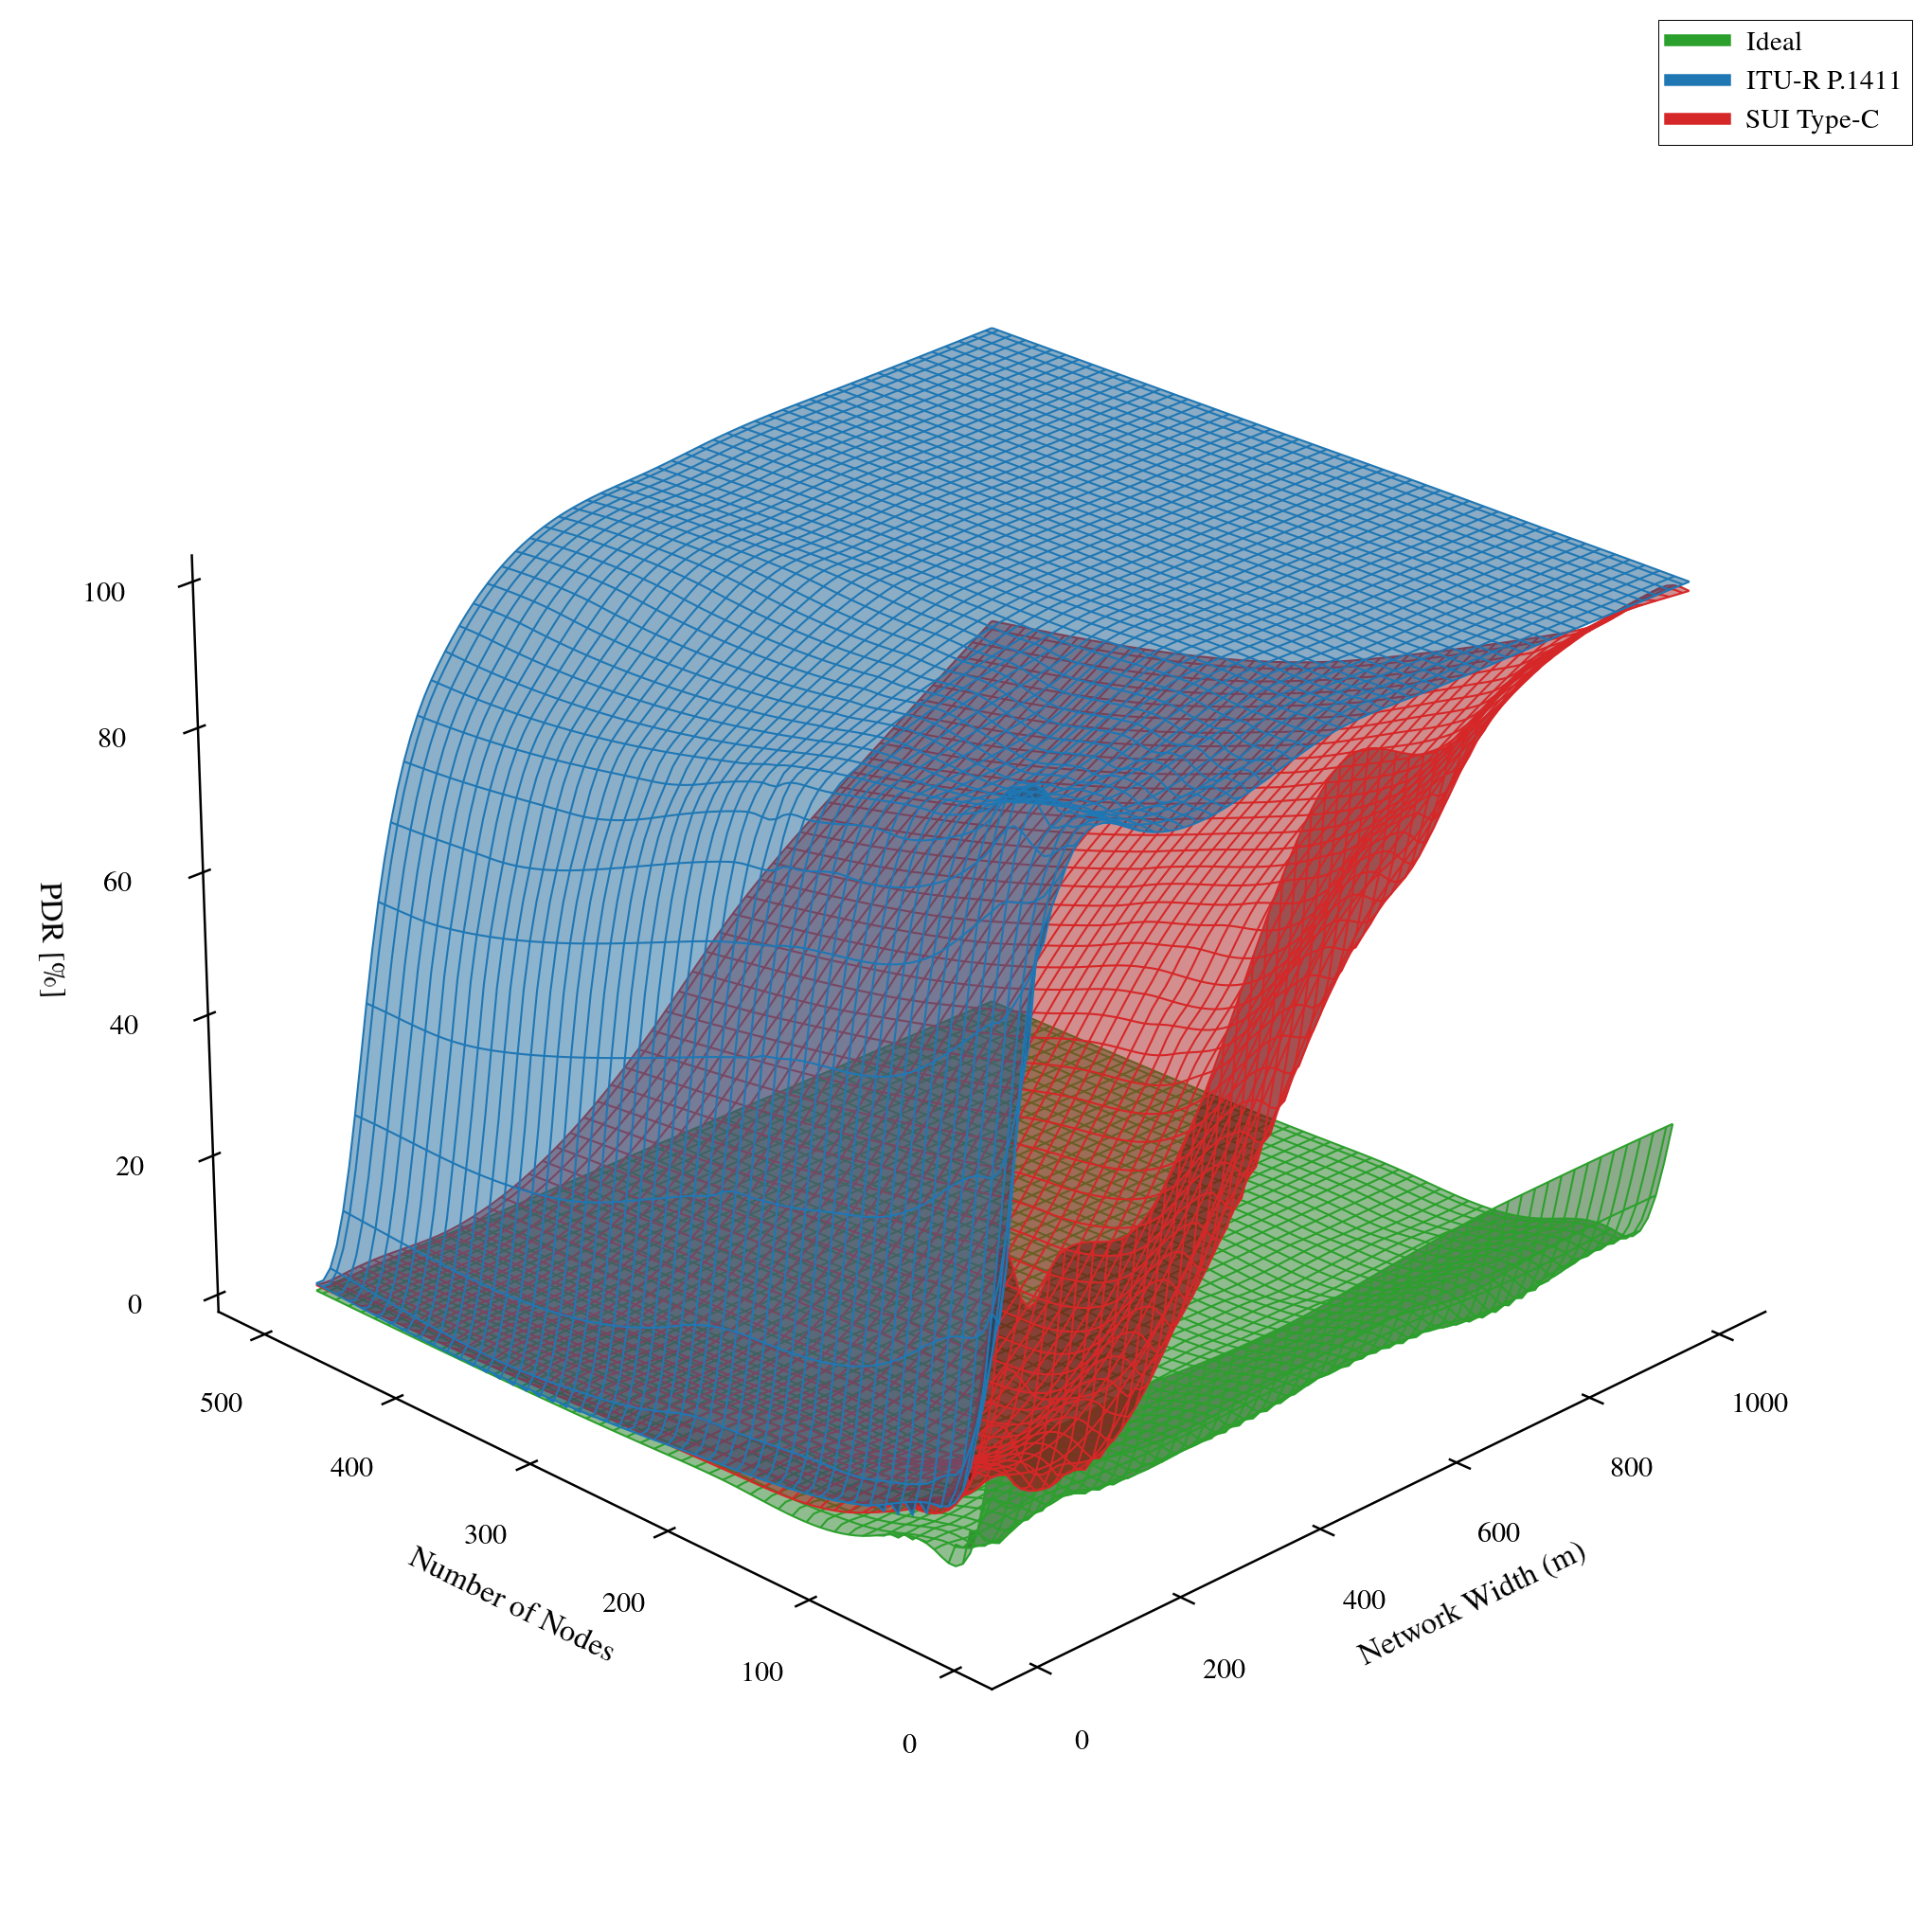

In [11]:
%matplotlib inline

metric = 'pdr'

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
models = [
    ("SUI_TypeC", "tab:red"),
    ("ITU_P1411", "tab:blue"),
    ("Ideal", "tab:green"),
]
zorder = 0
for model_name, color in models:

    X, Y, Z, L_values, N_values = build_grids(
        SINGLE_CHANNEL_ESP32_C6_DATA[model_name],
        metric
    )

    # Fine interpolation grid
    L_fine = np.linspace(min(L_values), max(L_values), 100)
    N_fine = np.linspace(min(N_values), max(N_values), 100)

    L_grid, N_grid = np.meshgrid(L_fine, N_fine)

    points = np.column_stack((X.ravel(), Y.ravel()))
    values = Z.ravel()

    Z_fine = griddata(
        points,
        values,
        (L_grid, N_grid),
        method='cubic'
    )

    # Surface
    ax.plot_surface(
        L_grid,
        N_grid,
        Z_fine,
        color=color,
        alpha=0.5,
        linewidth=0,
        antialiased=True,
        zorder=zorder
    )

    # Wireframe
    ax.plot_wireframe(
        L_grid,
        N_grid,
        Z_fine,
        color=color,
        linewidth=0.5,
        zorder=zorder,
        # rstride=10,
        # cstride=10,
        # alpha=0.8
    )

    # Original data points
    # ax.scatter(
    #     X,
    #     Y,
    #     Z,
    #     color=color,
    #     s=25,
    #     depthshade=True
    # )
    zorder -= 1
# Labels
ax.set_xlabel('Network Width (m)')
ax.set_ylabel('Number of Nodes')
ax.set_zlabel('PDR [\%]')

# Nice viewing angle
ax.view_init(elev=25, azim=-135)

# Cleaner background
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

# Remove pane borders
ax.xaxis.pane.set_edgecolor('white')
ax.yaxis.pane.set_edgecolor('white')
ax.zaxis.pane.set_edgecolor('white')

# Hide 3D grid completely
ax.xaxis._axinfo["grid"]['linewidth'] = 0
ax.yaxis._axinfo["grid"]['linewidth'] = 0
ax.zaxis._axinfo["grid"]['linewidth'] = 0

# Legend
legend_elements = [
    Line2D([0], [0], color='tab:green', lw=3, label='Ideal'),
    Line2D([0], [0], color='tab:blue', lw=3, label='ITU-R P.1411'),
    Line2D([0], [0], color='tab:red', lw=3, label='SUI Type-C')
]

ax.legend(
    handles=legend_elements,
    loc='best',
)

ax.set_box_aspect(aspect=None, zoom=0.9)

plt.tight_layout()
plt.show()

<>:65: SyntaxWarning: invalid escape sequence '\%'
<>:65: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_190159/2288145538.py:65: SyntaxWarning: invalid escape sequence '\%'
  ax.set_zlabel('PDR [\%]', fontsize=8, labelpad=4)


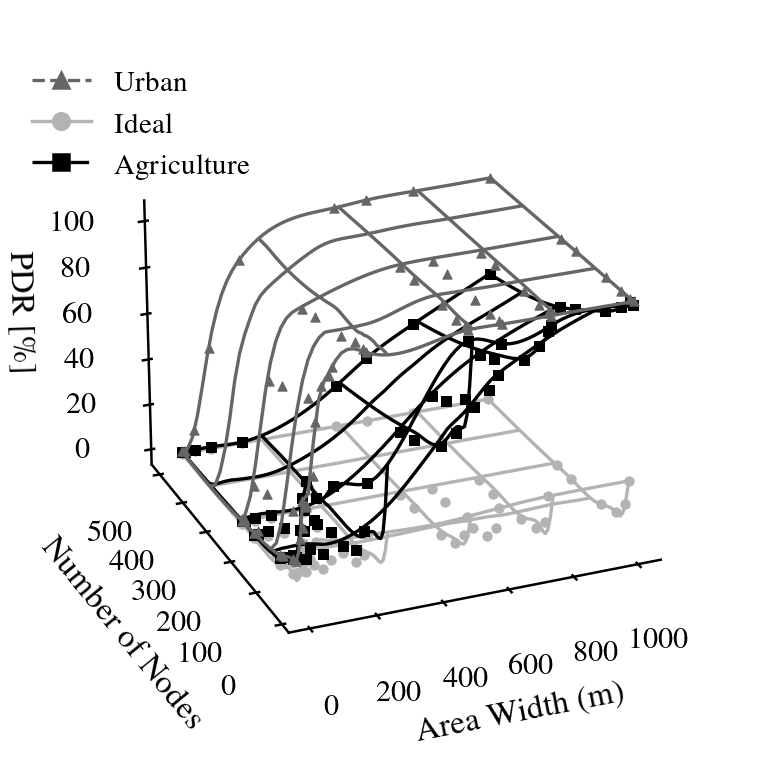

In [12]:
fig = plt.figure(figsize=(3.5, 2.8))   # IEEE single-column
ax = fig.add_subplot(111, projection='3d')
zorder = 0
models = [
    ("ITU_P1411",  "0.4", "--", "^", "Urban"),
    ("Ideal",        "0.7", "-",  "o", "Ideal"),
    ("SUI_TypeC",   "k",   "-.", "s", "Agriculture"),
]
legend_elements = []
for model_name, color, linestyle, marker, label in models:

    X, Y, Z, L_values, N_values = build_grids(
        SINGLE_CHANNEL_ESP32_C6_DATA[model_name],
        metric
    )

    # interpolation grid
    L_fine = np.linspace(min(L_values), max(L_values), 60)
    N_fine = np.linspace(min(N_values), max(N_values), 60)

    L_grid, N_grid = np.meshgrid(L_fine, N_fine)

    points = np.column_stack((X.ravel(), Y.ravel()))
    values = Z.ravel()

    Z_fine = griddata(
        points,
        values,
        (L_grid, N_grid),
        method='cubic'
    )

    # wireframe only
    ax.plot_wireframe(
        L_grid,
        N_grid,
        Z_fine,
        color=color,
        linewidth=0.8,
        rstride=15,
        cstride=15,
        zorder=zorder,
    )

    # simulation points
    ax.scatter(
        X,
        Y,
        Z,
        color=color,
        marker=marker,
        s=5,
        depthshade=False
    )
    zorder += 1

    legend_elements.append(
        Line2D([0], [0], color=color, linestyle=linestyle, marker=marker,
           label=label)
    )

# Labels
ax.set_xlabel('Area Width (m)', fontsize=8, labelpad=4)
ax.set_ylabel('Number of Nodes', fontsize=8, labelpad=4)
ax.set_zlabel('PDR [\%]', fontsize=8, labelpad=4)

ax.tick_params(labelsize=7)

# View angle
ax.view_init(elev=25, azim=-112.5)

# Remove panes
for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis.pane.fill = False
    axis.pane.set_edgecolor('white')

# Light grid
ax.grid(False)


ax.legend(
    handles=legend_elements,
    fontsize=7,
    frameon=False,
    loc='upper left',
    bbox_to_anchor=(0.0,0.95)
)
ax.set_box_aspect(aspect=None, zoom=0.8)

plt.tight_layout()
plt.savefig(
    "/mnt/Program/All/Routing-Protocols/_docs/Paper 2026/MSWiM/assets/esp32_c6_pdr_operational_regions_3d.png",
    bbox_inches="tight",
    dpi=600
)

<>:175: SyntaxWarning: invalid escape sequence '\%'
<>:175: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_190159/3799496749.py:175: SyntaxWarning: invalid escape sequence '\%'
  "PDR [\%]",


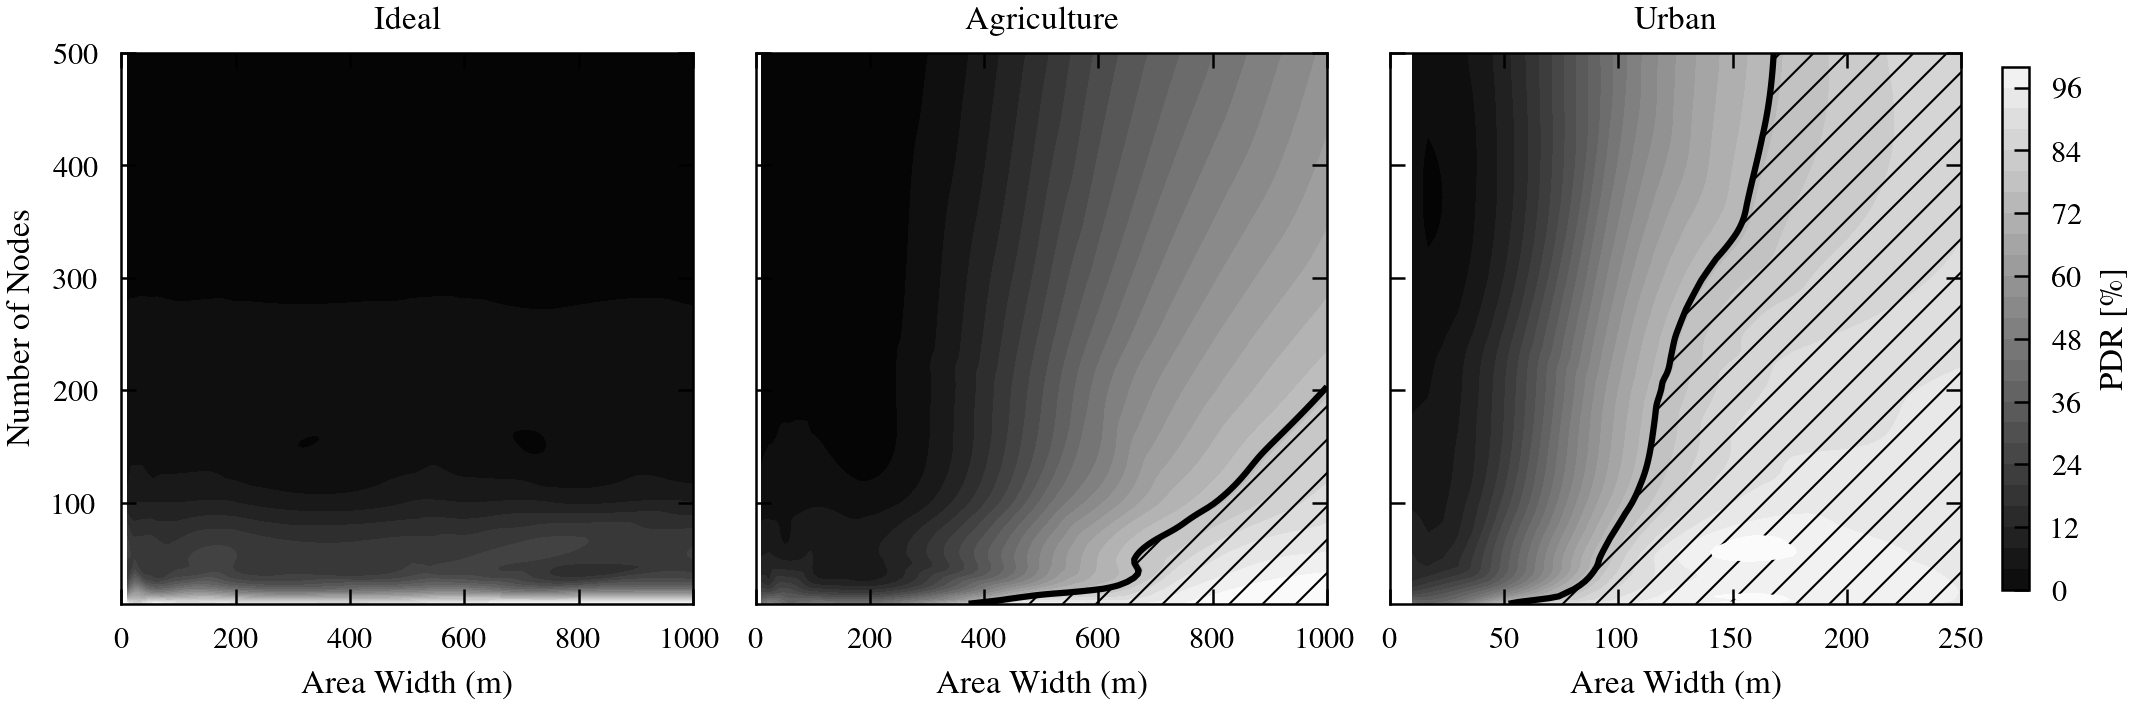

In [13]:
fig, axes = plt.subplots(
    1, 3,
    figsize=(7.16, 2.4),   # IEEE double-column width
    sharey=True,
    constrained_layout=True
)

models = [
    ("Ideal", "Ideal"),
    ("SUI_TypeC", "Agriculture"),
    ("ITU_P1411", "Urban"),
]

threshold = 75

for idx, (ax, (key, title)) in enumerate(zip(axes, models)):


    X, Y, Z, L_values, N_values = build_grids(
        SINGLE_CHANNEL_ESP32_C6_DATA[key],
        metric='pdr'
    )

    L_fine = np.linspace(min(L_values), max(L_values), 150)
    N_fine = np.linspace(min(N_values), max(N_values), 150)

    L_grid, N_grid = np.meshgrid(
        L_fine,
        N_fine
    )

    Z_fine = griddata(
        np.column_stack((X.ravel(), Y.ravel())),
        Z.ravel(),
        (L_grid, N_grid),
        method='cubic'
    )

    # Main contour map
    cf = ax.contourf(
        L_grid,
        N_grid,
        Z_fine,
        levels=25,
        cmap='binary_r'
    )

    # Iso-PDR line
    ax.contour(
        L_grid,
        N_grid,
        Z_fine,
        levels=[threshold],
        colors='black',
        linewidths=1.5
    )

    # Region satisfying requirement
    ax.contourf(
        L_grid,
        N_grid,
        Z_fine,
        levels=[threshold, 100],
        colors='none',
        hatches=['///']
    )

    # Original simulation points
    # ax.scatter(
    #     X,
    #     Y,
    #     s=8,
    #     c='k',
    #     alpha=0.4
    # )

    ax.set_title(title, fontsize=8)

    ax.tick_params(
        labelsize=7,
        direction='in'
    )

    if idx == 2:

        # axins = zoomed_inset_axes(
        #     ax,
        #     zoom=2.5,
        #     loc='upper left'
        # )

        # # redraw contour on inset
        # axins.contourf(
        #     L_grid,
        #     N_grid,
        #     Z_fine,
        #     levels=25,
        #     cmap='binary_r'
        # )

        # axins.contour(
        #     L_grid,
        #     N_grid,
        #     Z_fine,
        #     levels=[threshold],
        #     colors='black',
        #     linewidths=1.0
        # )

        # axins.contourf(
        #     L_grid,
        #     N_grid,
        #     Z_fine,
        #     levels=[threshold, 100],
        #     colors='none',
        #     hatches=['///']
        # )

        # axins.scatter(
        #     X,
        #     Y,
        #     s=5,
        #     c='k',
        #     alpha=0.3
        # )

        # # Region to zoom
        # N1, N2 = 10, 50
        # L1, L2 = 450, 500

        # axins.set_xlim(L1, L2)
        # axins.set_ylim(N1, N2)

        # axins.set_xticks([])
        # axins.set_yticks([])

        # mark_inset(
        #     ax,
        #     axins,
        #     loc1=3,
        #     loc2=1,
        #     fc="none",
        #     ec="black",
        #     color='w',
        #     lw=0.8
        # )
        L1, L2 = 0, 250
        ax.set_xlim(L1, L2)

        # N1, N2 = 10, 50
        # ax.set_ylim(N1, N2)
    else:
        L1, L2 = 0, 1000
        ax.set_xlim(L1, L2)

axes[0].set_ylabel(
    "Number of Nodes",
    fontsize=8
)

for ax in axes:
    ax.set_xlabel(
        "Area Width (m)",
        fontsize=8
    )

cbar = fig.colorbar(
    cf,
    ax=axes,
    pad=0.01,
    shrink=0.95
)

cbar.set_label(
    "PDR [\%]",
    fontsize=8
)
cbar.ax.set_ylim(bottom=0, top=100) 
cbar.ax.tick_params(labelsize=7)

plt.savefig(
    "/mnt/Program/All/Routing-Protocols/_docs/Paper 2026/MSWiM/assets/esp32_c6_pdr_operational_regions.png",
    bbox_inches="tight",
    dpi=600
)
plt.show()

## 2) Latency

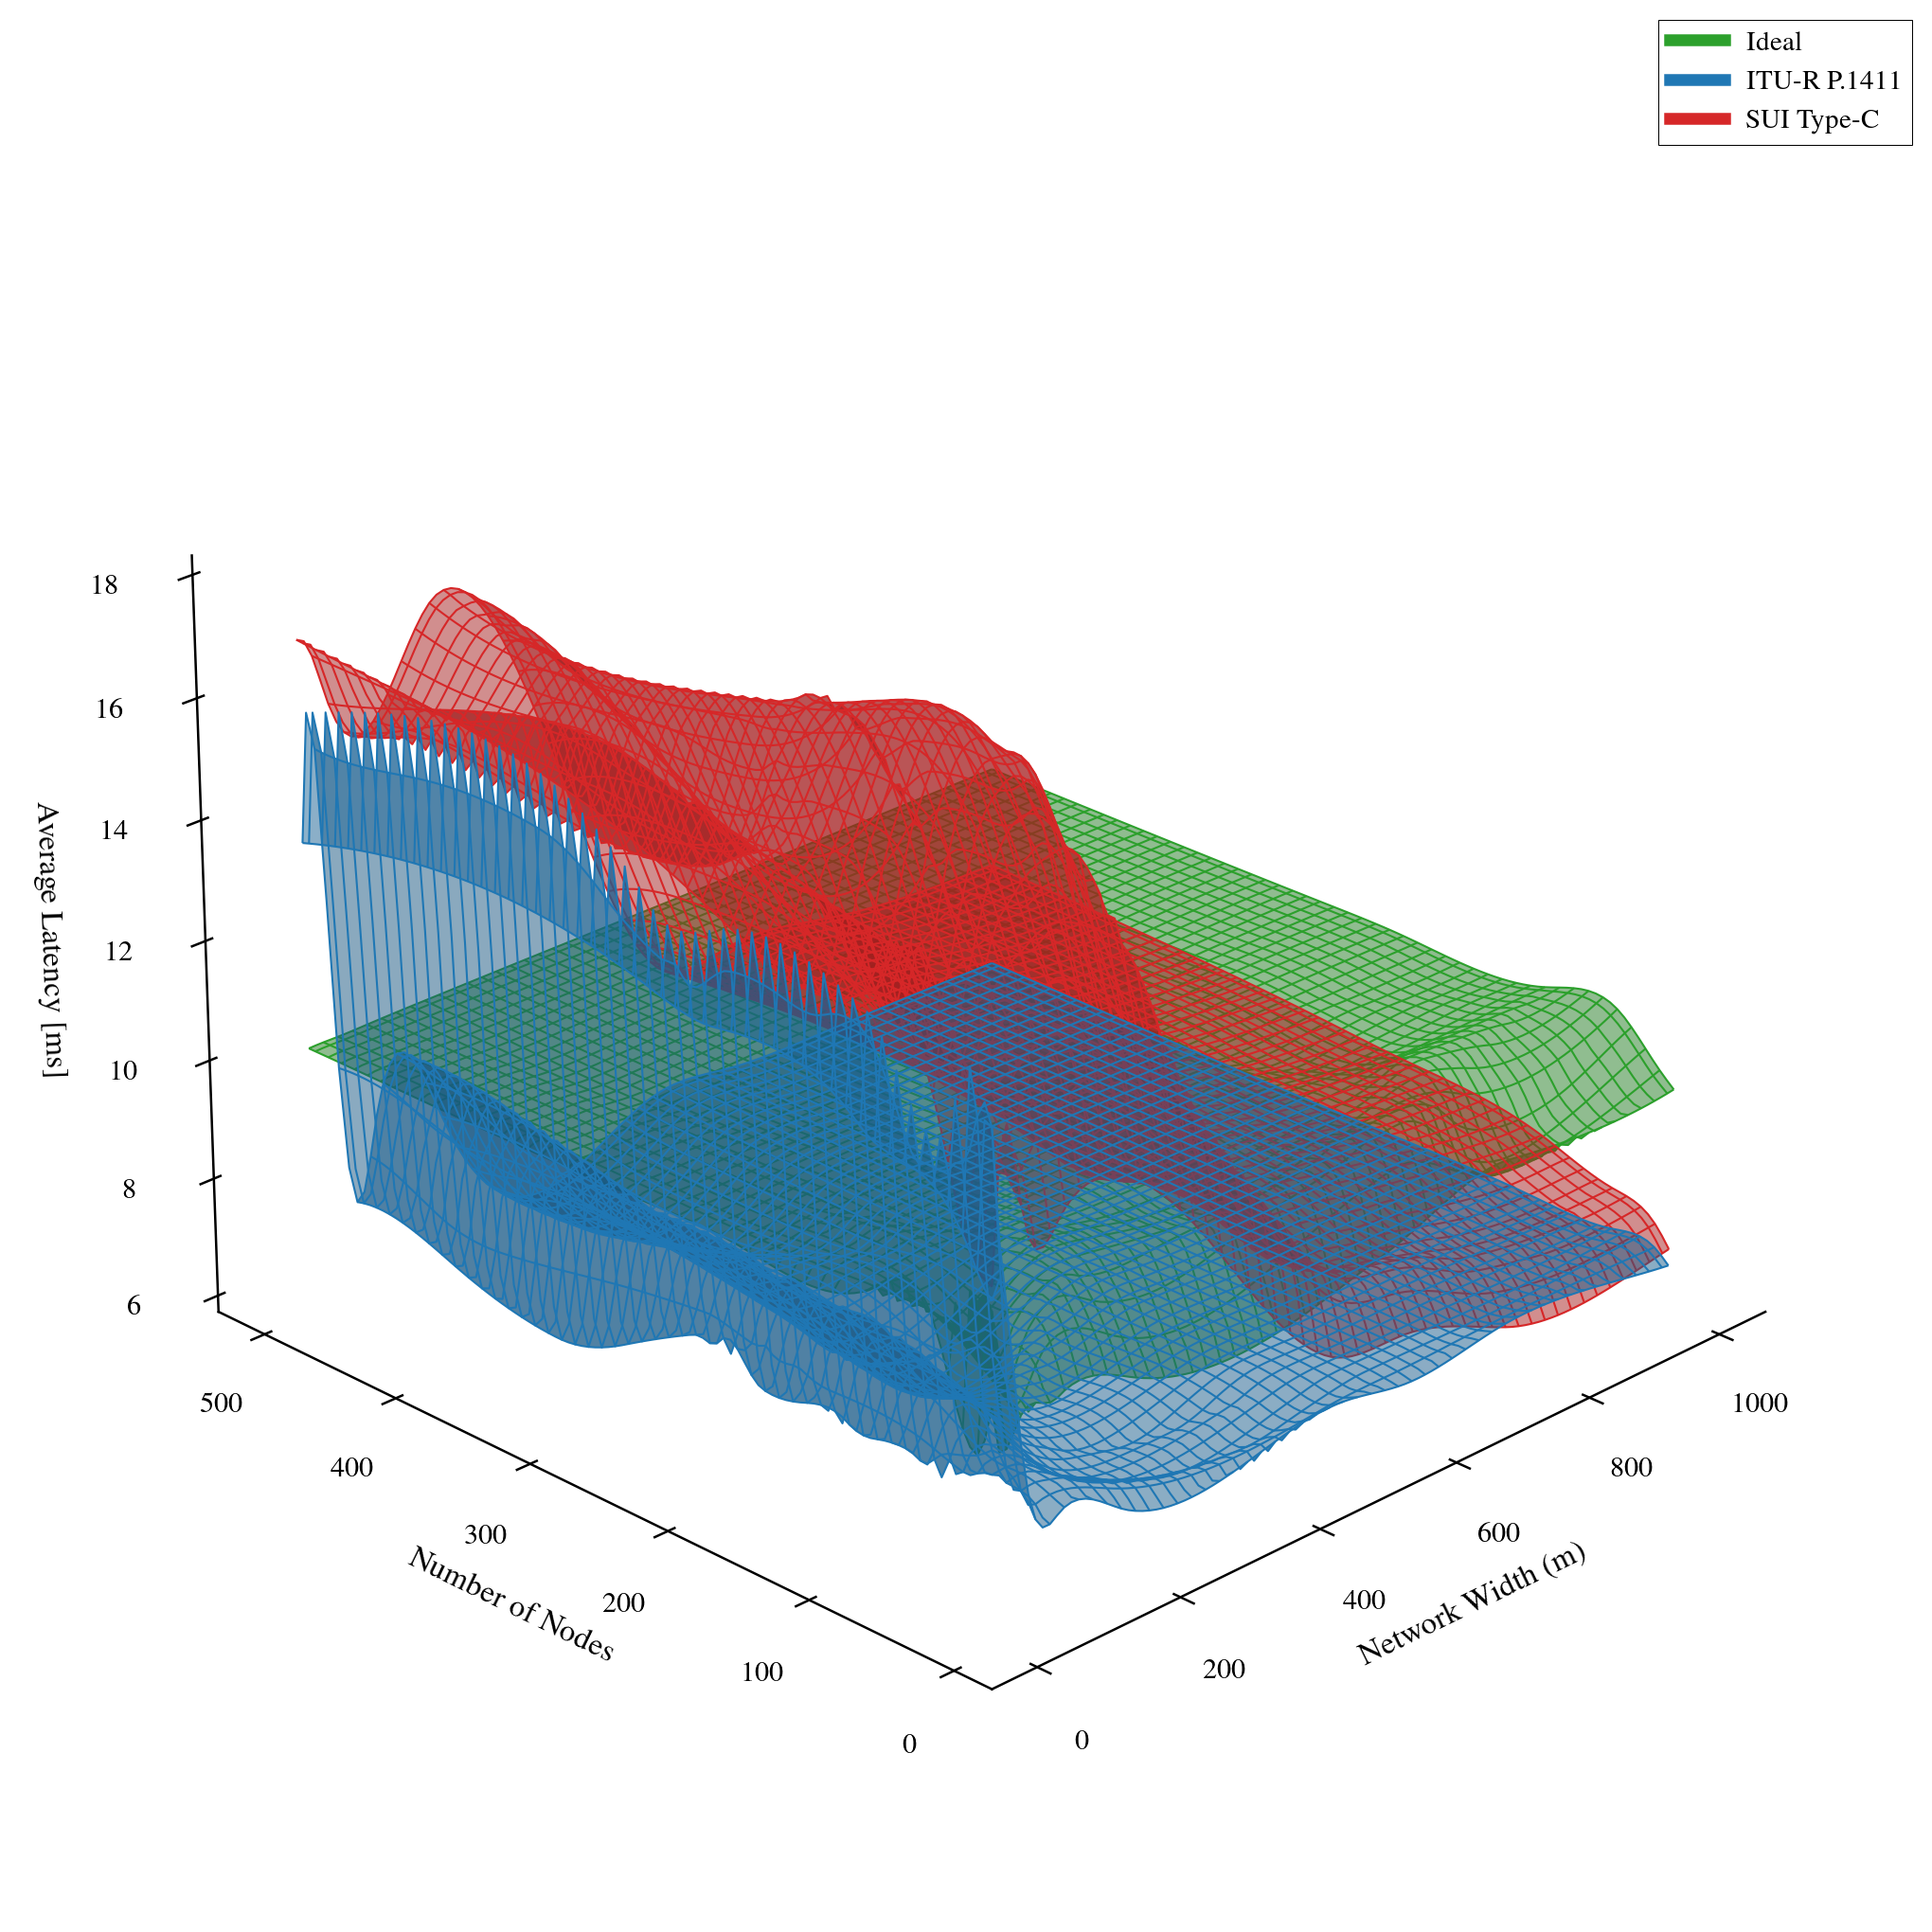

In [14]:

metric = 'avg_latency_ms'

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
models = [
    ("SUI_TypeC", "tab:red"),
    ("ITU_P1411", "tab:blue"),
    ("Ideal", "tab:green"),
]
zorder = 0
for model_name, color in models:

    X, Y, Z, L_values, N_values = build_grids(
        SINGLE_CHANNEL_ESP32_C6_DATA[model_name],
        metric
    )

    # Fine interpolation grid
    L_fine = np.linspace(min(L_values), max(L_values), 100)
    N_fine = np.linspace(min(N_values), max(N_values), 100)

    L_grid, N_grid = np.meshgrid(L_fine, N_fine)

    points = np.column_stack((X.ravel(), Y.ravel()))
    values = Z.ravel()

    Z_fine = griddata(
        points,
        values,
        (L_grid, N_grid),
        method='cubic'
    )

    # Surface
    ax.plot_surface(
        L_grid,
        N_grid,
        Z_fine,
        color=color,
        alpha=0.5,
        linewidth=0,
        antialiased=True,
        zorder=zorder
    )

    # Wireframe
    ax.plot_wireframe(
        L_grid,
        N_grid,
        Z_fine,
        color=color,
        linewidth=0.5,
        zorder=zorder,
        # rstride=10,
        # cstride=10,
        # alpha=0.8
    )

    # Original data points
    # ax.scatter(
    #     X,
    #     Y,
    #     Z,
    #     color=color,
    #     s=25,
    #     depthshade=True
    # )
    zorder -= 1
# Labels
ax.set_xlabel('Network Width (m)')
ax.set_ylabel('Number of Nodes')
ax.set_zlabel('Average Latency [ms]')

# Nice viewing angle
ax.view_init(elev=25, azim=-135)

# Cleaner background
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

# Remove pane borders
ax.xaxis.pane.set_edgecolor('white')
ax.yaxis.pane.set_edgecolor('white')
ax.zaxis.pane.set_edgecolor('white')

# Hide 3D grid completely
ax.xaxis._axinfo["grid"]['linewidth'] = 0
ax.yaxis._axinfo["grid"]['linewidth'] = 0
ax.zaxis._axinfo["grid"]['linewidth'] = 0

# Legend
legend_elements = [
    Line2D([0], [0], color='tab:green', lw=3, label='Ideal'),
    Line2D([0], [0], color='tab:blue', lw=3, label='ITU-R P.1411'),
    Line2D([0], [0], color='tab:red', lw=3, label='SUI Type-C')
]

ax.legend(
    handles=legend_elements,
    loc='best',
)

ax.set_box_aspect(aspect=None, zoom=0.9)

plt.tight_layout()
plt.show()

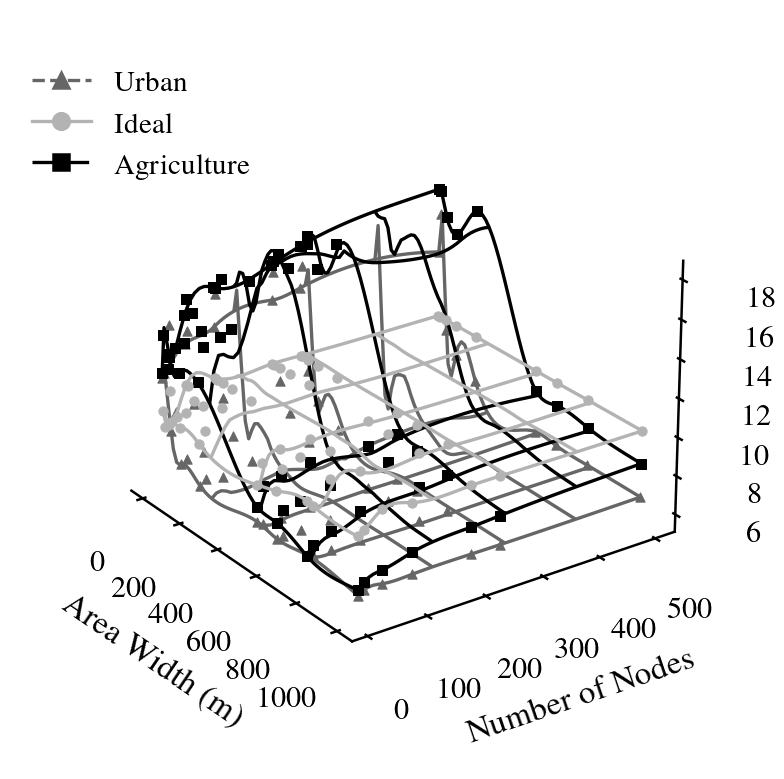

In [15]:
metric = 'avg_latency_ms'

fig = plt.figure(figsize=(3.5, 2.8))   # IEEE single-column
ax = fig.add_subplot(111, projection='3d')
zorder = 0
models = [
    ("ITU_P1411",  "0.4", "--", "^", "Urban"),
    ("Ideal",        "0.7", "-",  "o", "Ideal"),
    ("SUI_TypeC",   "k",   "-.", "s", "Agriculture"),
]
legend_elements = []
for model_name, color, linestyle, marker, label in models:

    X, Y, Z, L_values, N_values = build_grids(
        SINGLE_CHANNEL_ESP32_C6_DATA[model_name],
        metric
    )

    # interpolation grid
    L_fine = np.linspace(min(L_values), max(L_values), 60)
    N_fine = np.linspace(min(N_values), max(N_values), 60)

    L_grid, N_grid = np.meshgrid(L_fine, N_fine)

    points = np.column_stack((X.ravel(), Y.ravel()))
    values = Z.ravel()

    Z_fine = griddata(
        points,
        values,
        (L_grid, N_grid),
        method='cubic'
    )

    # wireframe only
    ax.plot_wireframe(
        L_grid,
        N_grid,
        Z_fine,
        color=color,
        linewidth=0.8,
        rstride=15,
        cstride=15,
        zorder=zorder,
    )

    # simulation points
    ax.scatter(
        X,
        Y,
        Z,
        color=color,
        marker=marker,
        s=5,
        depthshade=False
    )
    zorder += 1

    legend_elements.append(
        Line2D([0], [0], color=color, linestyle=linestyle, marker=marker,
           label=label)
    )

# Labels
ax.set_xlabel('Area Width (m)', fontsize=8, labelpad=4)
ax.set_ylabel('Number of Nodes', fontsize=8, labelpad=4)
ax.set_zlabel('Average Latency [ms]', fontsize=8, labelpad=4)

ax.tick_params(labelsize=7)

# View angle
ax.view_init(elev=25, azim=-35.5)

# Remove panes
for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis.pane.fill = False
    axis.pane.set_edgecolor('white')

# Light grid
ax.grid(False)


ax.legend(
    handles=legend_elements,
    fontsize=7,
    frameon=False,
    loc='upper left',
    bbox_to_anchor=(0.0,0.95)
)
ax.set_box_aspect(aspect=None, zoom=0.8)

plt.tight_layout()
plt.savefig(
    "/mnt/Program/All/Routing-Protocols/_docs/Paper 2026/MSWiM/assets/operational_regions_3d.png",
    bbox_inches="tight",
    dpi=600
)

In [16]:
3470/60

57.833333333333336

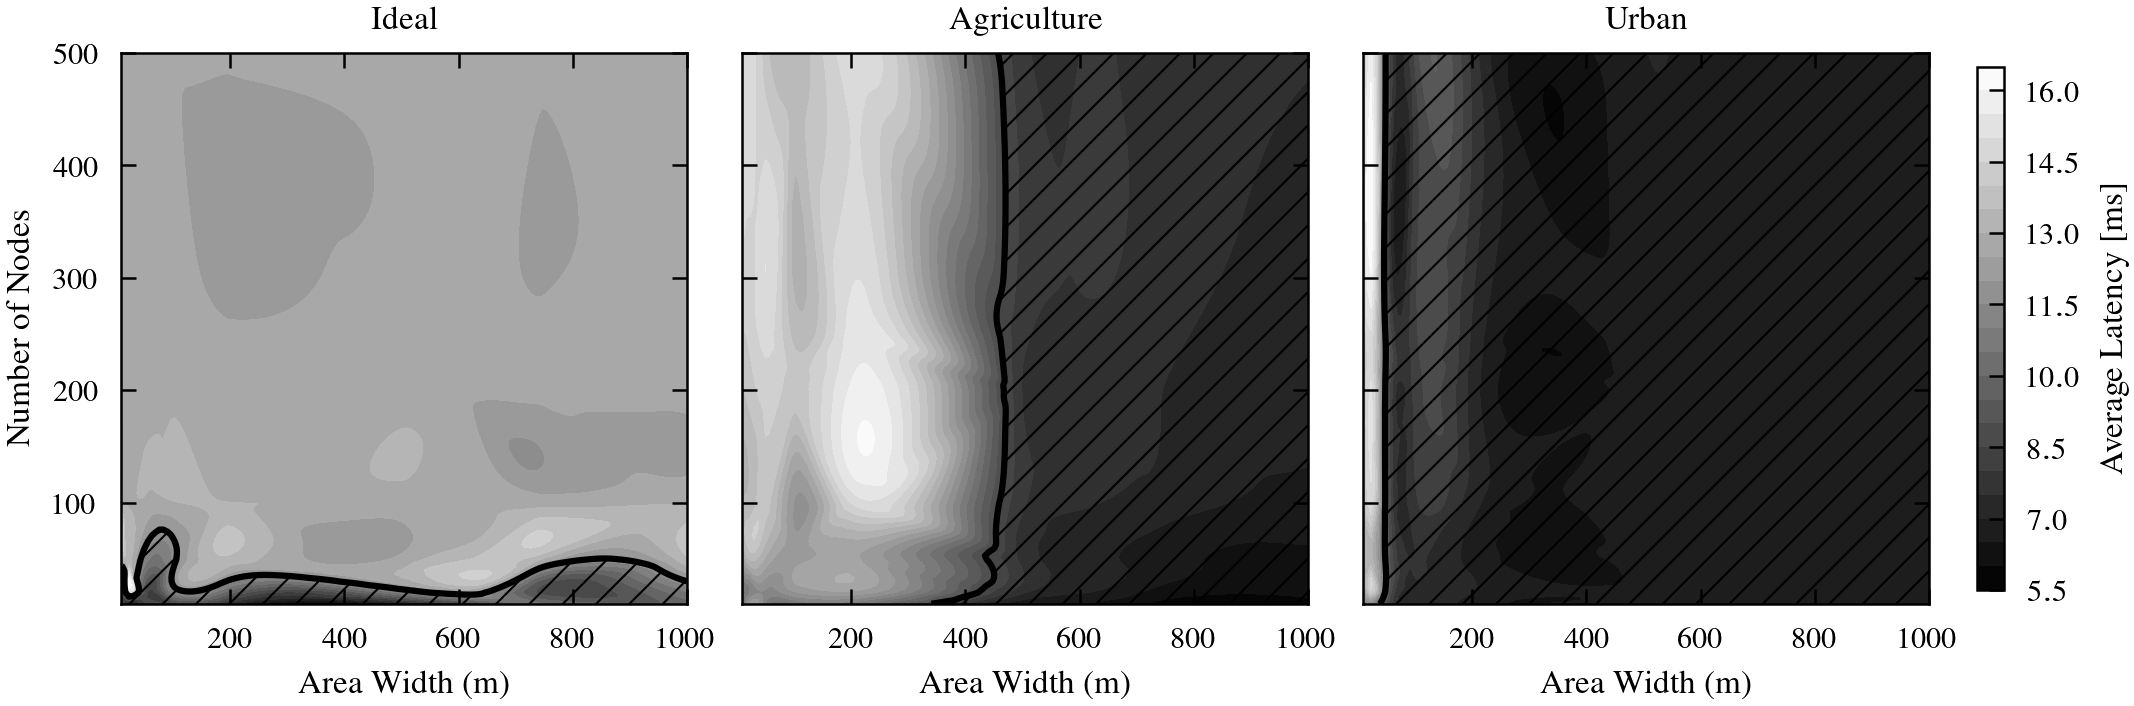

In [17]:
fig, axes = plt.subplots(
    1, 3,
    figsize=(7.16, 2.4),   # IEEE double-column width
    sharey=True,
    constrained_layout=True
)

models = [
    ("Ideal", "Ideal"),
    ("SUI_TypeC", "Agriculture"),
    ("ITU_P1411", "Urban"),
]

threshold = 10

for idx, (ax, (key, title)) in enumerate(zip(axes, models)):


    X, Y, Z, L_values, N_values = build_grids(
        SINGLE_CHANNEL_ESP32_C6_DATA[key],
        metric=metric
    )

    L_fine = np.linspace(min(L_values), max(L_values), 150)
    N_fine = np.linspace(min(N_values), max(N_values), 150)

    L_grid, N_grid = np.meshgrid(
        L_fine,
        N_fine
    )

    Z_fine = griddata(
        np.column_stack((X.ravel(), Y.ravel())),
        Z.ravel(),
        (L_grid, N_grid),
        method='cubic'
    )

    # Main contour map
    cf = ax.contourf(
        L_grid,
        N_grid,
        Z_fine,
        levels=25,
        cmap='binary_r'
    )

    # Iso-PDR line
    ax.contour(
        L_grid,
        N_grid,
        Z_fine,
        levels=[threshold],
        colors='black',
        linewidths=1.5
    )

    # Region satisfying requirement
    ax.contourf(
        L_grid,
        N_grid,
        Z_fine,
        levels=[0, threshold],
        colors='none',
        hatches=['///']
    )

    # Original simulation points
    # ax.scatter(
    #     X,
    #     Y,
    #     s=8,
    #     c='k',
    #     alpha=0.4
    # )

    ax.set_title(title, fontsize=8)

    ax.tick_params(
        labelsize=7,
        direction='in'
    )

    # if idx == 2:

    #     # axins = zoomed_inset_axes(
    #     #     ax,
    #     #     zoom=2.5,
    #     #     loc='upper left'
    #     # )

    #     # # redraw contour on inset
    #     # axins.contourf(
    #     #     L_grid,
    #     #     N_grid,
    #     #     Z_fine,
    #     #     levels=25,
    #     #     cmap='binary_r'
    #     # )

    #     # axins.contour(
    #     #     L_grid,
    #     #     N_grid,
    #     #     Z_fine,
    #     #     levels=[threshold],
    #     #     colors='black',
    #     #     linewidths=1.0
    #     # )

    #     # axins.contourf(
    #     #     L_grid,
    #     #     N_grid,
    #     #     Z_fine,
    #     #     levels=[threshold, 100],
    #     #     colors='none',
    #     #     hatches=['///']
    #     # )

    #     # axins.scatter(
    #     #     X,
    #     #     Y,
    #     #     s=5,
    #     #     c='k',
    #     #     alpha=0.3
    #     # )

    #     # # Region to zoom
    #     # N1, N2 = 10, 50
    #     # L1, L2 = 450, 500

    #     # axins.set_xlim(L1, L2)
    #     # axins.set_ylim(N1, N2)

    #     # axins.set_xticks([])
    #     # axins.set_yticks([])

    #     # mark_inset(
    #     #     ax,
    #     #     axins,
    #     #     loc1=3,
    #     #     loc2=1,
    #     #     fc="none",
    #     #     ec="black",
    #     #     color='w',
    #     #     lw=0.8
    #     # )
    #     L1, L2 = 0, 250
    #     ax.set_xlim(L1, L2)

    #     # N1, N2 = 10, 50
    #     # ax.set_ylim(N1, N2)
    # else:
    #     L1, L2 = 0, 1000
    #     ax.set_xlim(L1, L2)

axes[0].set_ylabel(
    "Number of Nodes",
    fontsize=8
)

for ax in axes:
    ax.set_xlabel(
        "Area Width (m)",
        fontsize=8
    )

cbar = fig.colorbar(
    cf,
    ax=axes,
    pad=0.01,
    shrink=0.95
)

cbar.set_label(
    "Average Latency [ms]",
    fontsize=8
)
cbar.ax.tick_params(labelsize=7)

plt.savefig(
    "/mnt/Program/All/Routing-Protocols/_docs/Paper 2026/MSWiM/assets/latency_operational_regions.png",
    bbox_inches="tight",
    dpi=600
)
plt.show()

## 3) PDR vs Network Density

<>:85: SyntaxWarning: invalid escape sequence '\%'
<>:85: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_190159/186067036.py:85: SyntaxWarning: invalid escape sequence '\%'
  ax.set_ylabel('PDR [\%]', fontsize=8, labelpad=4)
/mnt/Program/All/WSN-Simulator-for-IEEE-802.15.4-Network/.env/lib/python3.12/site-packages/IPython/core/events.py:100: UserWarning: AutoMinorLocator does not work on logarithmic scales
  func(*args, **kwargs)
/mnt/Program/All/WSN-Simulator-for-IEEE-802.15.4-Network/.env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: AutoMinorLocator does not work on logarithmic scales
  fig.canvas.print_figure(bytes_io, **kw)


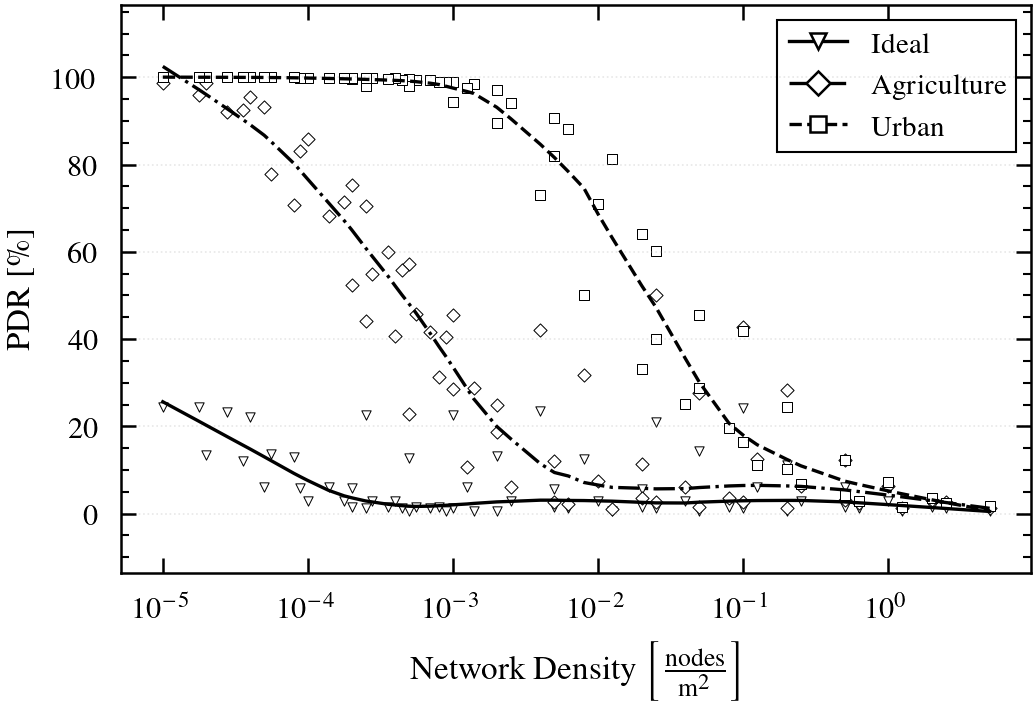

In [18]:
models = [
    ("Ideal",       "k", "-" , "v", "Ideal"),
    ("SUI_TypeC",   "k", "-.", "D", "Agriculture"),
    ("ITU_P1411",   "k", "--", "s", "Urban"),
]
legend_elements = []

degree = 8
fig, ax = plt.subplots(figsize=(3.5, 2.4), constrained_layout=True)
metric = 'pdr'

for model_name, color, linestyle, marker, label in models:
    densities = []
    values = []

    for (N, L), data in SINGLE_CHANNEL_ESP32_C6_DATA[model_name].items():
        vals = data.get(metric, [])
        if len(vals) == 0:
            continue

        density = N / (L ** 2)
        densities.append(density)
        values.append(np.mean(vals))
    
    densities = np.array(densities)
    values = np.array(values)

    # sort from high density to low density
    idx = np.argsort(densities)[::-1]
    densities = densities[idx]
    values = values[idx]

    # Fit polynomial on log10(density)
    
    x = np.log10(densities)
    y = values

    smoothed = lowess(
        y,
        x,
        frac=0.3,      # smoothing factor
        return_sorted=True
    )

    x_smooth = smoothed[:,0]
    y_smooth = smoothed[:,1]

    density_smooth = 10**x_smooth


    ax.scatter(
        densities,
        values,
        s=5,
        marker=marker,
        color=color,
        label=label,
        facecolor='w',
    )

    ax.plot(
        density_smooth,
        y_smooth,
        linestyle=linestyle,
        color=color,
        linewidth=0.8,
        markersize=4,
        markerfacecolor='white',
        markeredgewidth=0.6
    )

    ax.set_xscale('log')
    # ax.invert_xaxis()  # highest density on the left

        


    legend_elements.append(
        Line2D([0], [0], color=color, linestyle=linestyle, marker=marker, markerfacecolor='w',
           label=label)
    )

# Labels
ax.set_xlabel(r"Network Density $\left[\frac{\mathrm{nodes}}{\mathrm{m}^2}\right]$")
ax.set_ylabel('PDR [\%]', fontsize=8, labelpad=4)

ax.tick_params(labelsize=7)

ax.grid(False)


ax.legend(
    handles=legend_elements,
    frameon=True,
    fontsize=7,
    edgecolor='black',
    facecolor='none'
)
apply_pgfplots_style(
    ax,
    # xlim=(0, 52),
    y_pad=0.08
)



# Single Channel - CC2420

## 1) PDR 3D

<>:65: SyntaxWarning: invalid escape sequence '\%'
<>:65: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_190159/1569029224.py:65: SyntaxWarning: invalid escape sequence '\%'
  ax.set_zlabel('PDR [\%]', fontsize=8, labelpad=4)


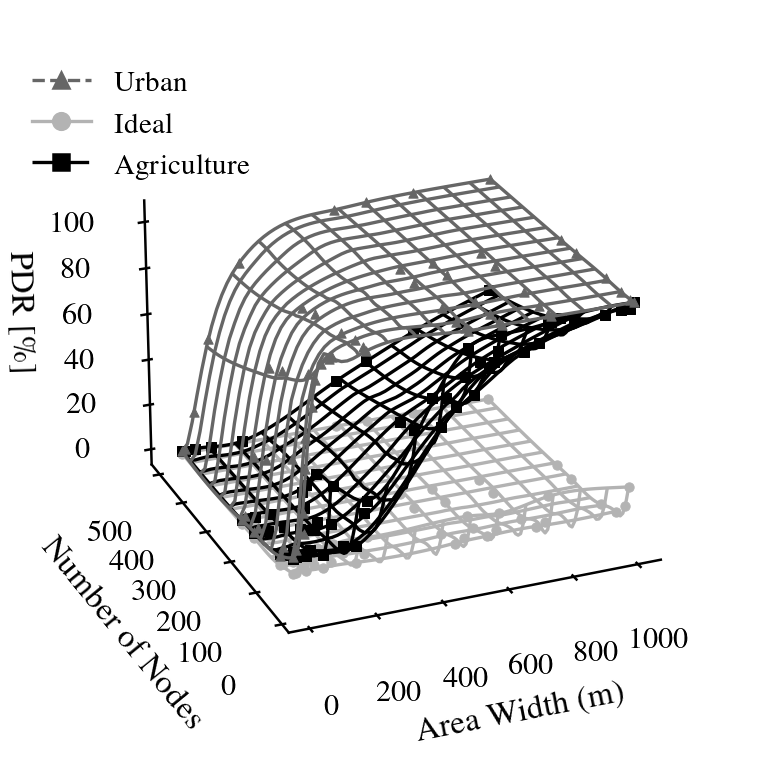

In [19]:
fig = plt.figure(figsize=(3.5, 2.8))   # IEEE single-column
ax = fig.add_subplot(111, projection='3d')
zorder = 0
models = [
    ("ITU_P1411",  "0.4", "--", "^", "Urban"),
    ("Ideal",        "0.7", "-",  "o", "Ideal"),
    ("SUI_TypeC",   "k",   "-.", "s", "Agriculture"),
]
legend_elements = []
for model_name, color, linestyle, marker, label in models:

    X, Y, Z, L_values, N_values = build_grids(
        SINGLE_CHANNEL_CC2420_DATA[model_name],
        metric
    )

    # interpolation grid
    L_fine = np.linspace(min(L_values), max(L_values), 60)
    N_fine = np.linspace(min(N_values), max(N_values), 60)

    L_grid, N_grid = np.meshgrid(L_fine, N_fine)

    points = np.column_stack((X.ravel(), Y.ravel()))
    values = Z.ravel()

    Z_fine = griddata(
        points,
        values,
        (L_grid, N_grid),
        method='cubic'
    )

    # wireframe only
    ax.plot_wireframe(
        L_grid,
        N_grid,
        Z_fine,
        color=color,
        linewidth=0.8,
        rstride=5,
        cstride=5,
        zorder=zorder,
    )

    # simulation points
    ax.scatter(
        X,
        Y,
        Z,
        color=color,
        marker=marker,
        s=5,
        depthshade=False
    )
    zorder += 1

    legend_elements.append(
        Line2D([0], [0], color=color, linestyle=linestyle, marker=marker,
           label=label)
    )

# Labels
ax.set_xlabel('Area Width (m)', fontsize=8, labelpad=4)
ax.set_ylabel('Number of Nodes', fontsize=8, labelpad=4)
ax.set_zlabel('PDR [\%]', fontsize=8, labelpad=4)

ax.tick_params(labelsize=7)

# View angle
ax.view_init(elev=25, azim=-112.5)

# Remove panes
for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis.pane.fill = False
    axis.pane.set_edgecolor('white')

# Light grid
ax.grid(False)


ax.legend(
    handles=legend_elements,
    fontsize=7,
    frameon=False,
    loc='upper left',
    bbox_to_anchor=(0.0,0.95)
)
ax.set_box_aspect(aspect=None, zoom=0.8)

plt.tight_layout()
plt.savefig(
    "/mnt/Program/All/Routing-Protocols/_docs/Paper 2026/MSWiM/assets/cc2420_c6_pdr_operational_regions_3d.png",
    bbox_inches="tight",
    dpi=600
)

## PDR contour

<>:182: SyntaxWarning: invalid escape sequence '\%'
<>:182: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_190159/4224997920.py:182: SyntaxWarning: invalid escape sequence '\%'
  "PDR [\%]",
/tmp/ipykernel_190159/4224997920.py:54: UserWarning: The following kwargs were not used by contour: 'edgecolors', 'linewidth'
  c1 = ax.contourf(


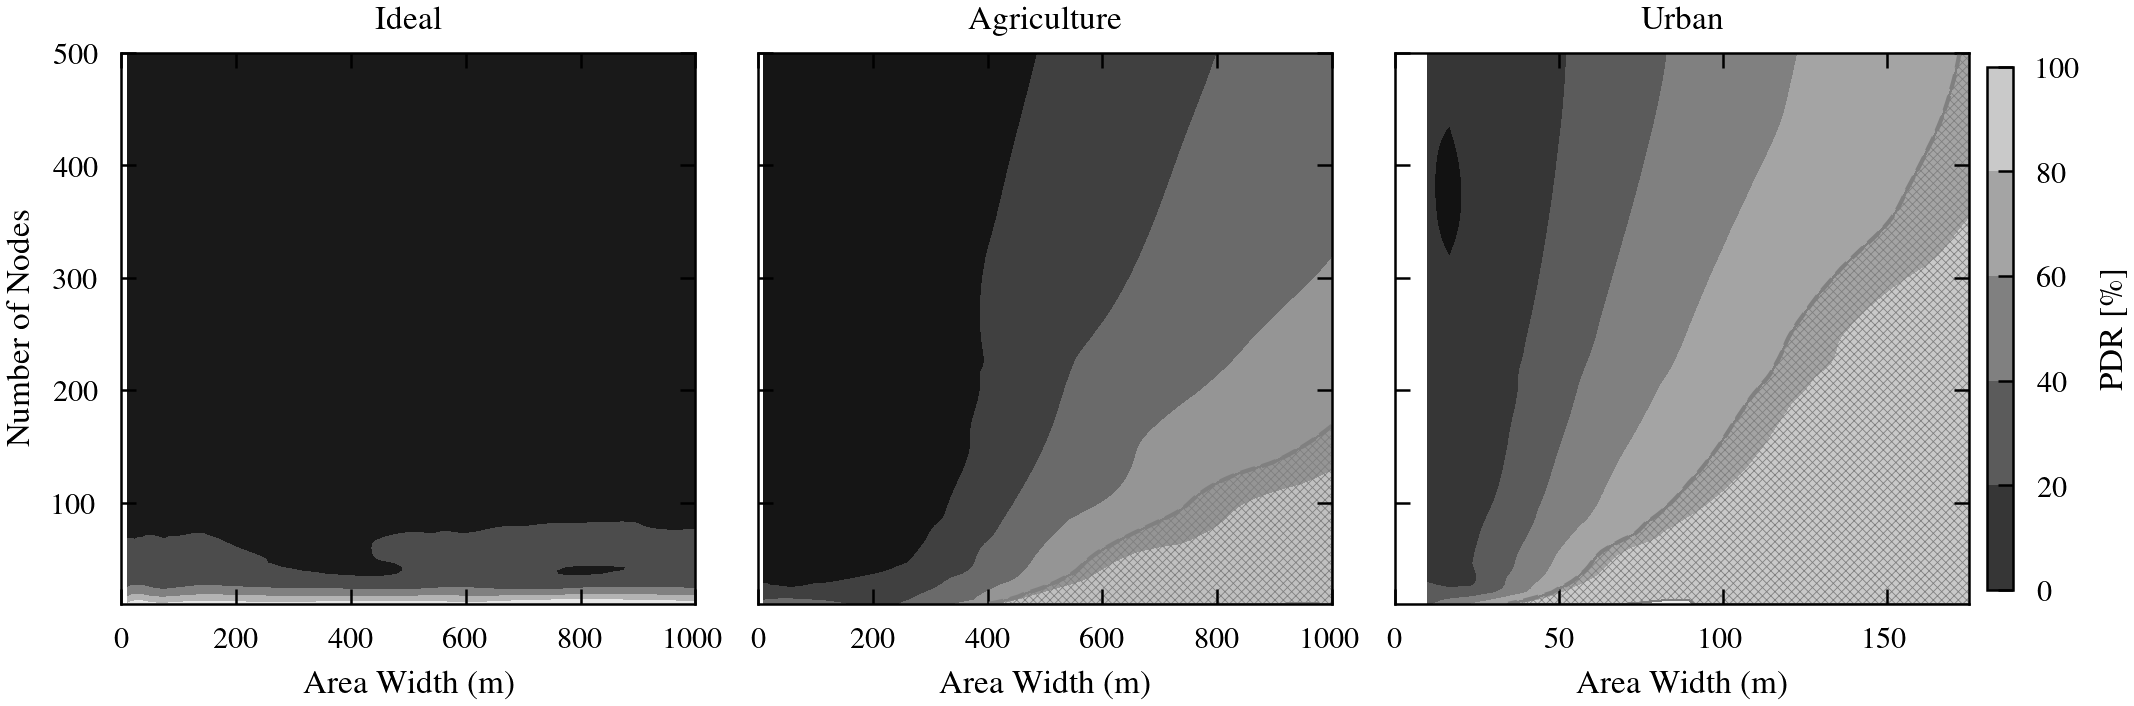

In [69]:
fig, axes = plt.subplots(
    1, 3,
    figsize=(7.16, 2.4),   # IEEE double-column width
    sharey=True,
    constrained_layout=True
)

models = [
    ("Ideal", "Ideal"),
    ("SUI_TypeC", "Agriculture"),
    ("ITU_P1411", "Urban"),
]

threshold = 75

for idx, (ax, (key, title)) in enumerate(zip(axes, models)):


    X, Y, Z, L_values, N_values = build_grids(
        SINGLE_CHANNEL_CC2420_DATA[key],
        metric='pdr'
    )

    L_fine = np.linspace(min(L_values), max(L_values), 150)
    N_fine = np.linspace(min(N_values), max(N_values), 150)

    L_grid, N_grid = np.meshgrid(
        L_fine,
        N_fine
    )

    Z_fine = griddata(
        np.column_stack((X.ravel(), Y.ravel())),
        Z.ravel(),
        (L_grid, N_grid),
        method='cubic'
    )

    

    # Main contour map
    cf = ax.contourf(
        L_grid,
        N_grid,
        Z_fine,
        levels=5,
        cmap='binary_r'
    )

    

    # Region satisfying requirement
    plt.rcParams['hatch.linewidth'] = 0.2
    c1 = ax.contourf(
        L_grid, N_grid, Z_fine,
        levels=[threshold, 100],
        colors='none',          # fill color (or use 'none' for transparent)
        edgecolors='gray',       # hatch color
        hatches=['xxxxxxxxxxxx'],
        linewidth=0.01,
    )
    c1.set_edgecolor((0.5, 0.5, 0.5, 1.0))

    # Iso-PDR line
    ax.contour(
        L_grid,
        N_grid,
        Z_fine,
        levels=[threshold],
        colors='gray',
        linestyles='--',
        linewidths=1
    )

    # Original simulation points
    # ax.scatter(
    #     X,
    #     Y,
    #     s=8,
    #     c='k',
    #     alpha=0.4
    # )

    ax.set_title(title, fontsize=8)

    ax.tick_params(
        labelsize=7,
        direction='in'
    )

    if idx == 2:

        # axins = zoomed_inset_axes(
        #     ax,
        #     zoom=2.5,
        #     loc='upper left'
        # )

        # # redraw contour on inset
        # axins.contourf(
        #     L_grid,
        #     N_grid,
        #     Z_fine,
        #     levels=25,
        #     cmap='binary_r'
        # )

        # axins.contour(
        #     L_grid,
        #     N_grid,
        #     Z_fine,
        #     levels=[threshold],
        #     colors='black',
        #     linewidths=1.0
        # )

        # axins.contourf(
        #     L_grid,
        #     N_grid,
        #     Z_fine,
        #     levels=[threshold, 100],
        #     colors='none',
        #     hatches=['///']
        # )

        # axins.scatter(
        #     X,
        #     Y,
        #     s=5,
        #     c='k',
        #     alpha=0.3
        # )

        # # Region to zoom
        # N1, N2 = 10, 50
        # L1, L2 = 450, 500

        # axins.set_xlim(L1, L2)
        # axins.set_ylim(N1, N2)

        # axins.set_xticks([])
        # axins.set_yticks([])

        # mark_inset(
        #     ax,
        #     axins,
        #     loc1=3,
        #     loc2=1,
        #     fc="none",
        #     ec="black",
        #     color='w',
        #     lw=0.8
        # )
        L1, L2 = 0, 175
        ax.set_xlim(L1, L2)

        # N1, N2 = 10, 50
        # ax.set_ylim(N1, N2)
    else:
        L1, L2 = 0, 1000
        ax.set_xlim(L1, L2)

axes[0].set_ylabel(
    "Number of Nodes",
    fontsize=8
)

for ax in axes:
    ax.set_xlabel(
        "Area Width (m)",
        fontsize=8
    )

cbar = fig.colorbar(
    cf,
    ax=axes,
    pad=0.01,
    shrink=0.95
)

cbar.set_label(
    "PDR [\%]",
    fontsize=8
)
cbar.ax.set_ylim(bottom=0, top=100) 
cbar.ax.tick_params(labelsize=7)

plt.savefig(
    "/mnt/Program/All/Routing-Protocols/_docs/Paper 2026/MSWiM/assets/cc2420_pdr_operational_regions.png",
    bbox_inches="tight",
    dpi=600
)
plt.show()

## 2) Average Latency Conusmption vs Network Density

/tmp/ipykernel_190159/2413969103.py:103: UserWarning: AutoMinorLocator does not work on logarithmic scales
  plt.savefig(


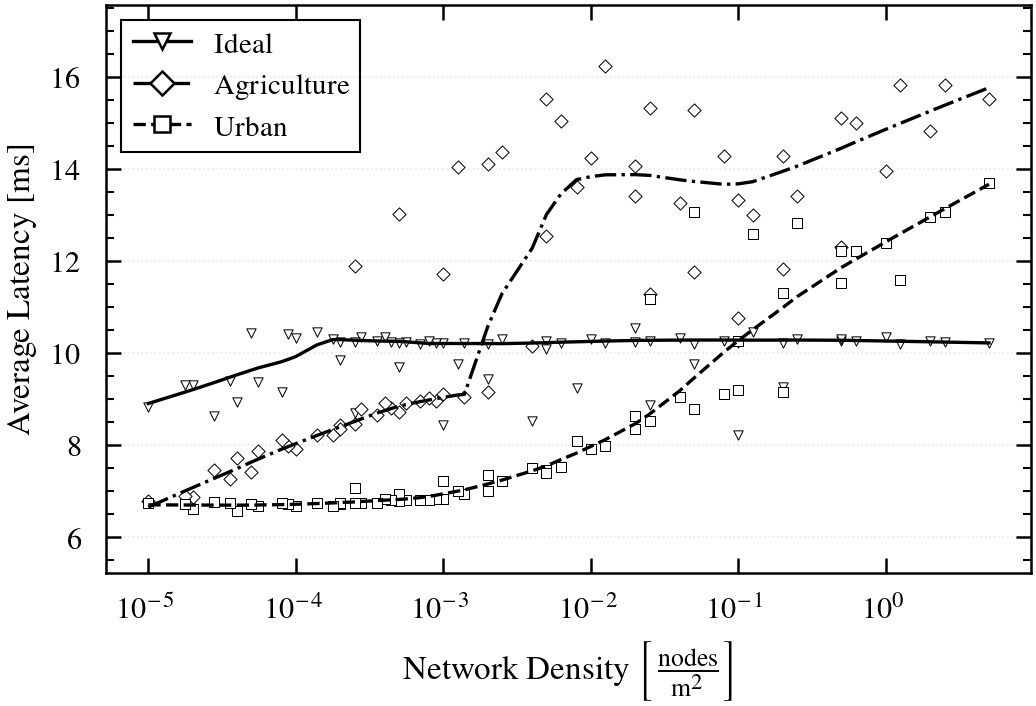

In [21]:
models = [
    ("Ideal",       "k", "-" , "v", "Ideal"),
    ("SUI_TypeC",   "k", "-.", "D", "Agriculture"),
    ("ITU_P1411",   "k", "--", "s", "Urban"),
]
legend_elements = []
metric = 'avg_latency_ms'
degree = 25
fig, ax = plt.subplots(figsize=(3.5, 2.4), constrained_layout=True)


for model_name, color, linestyle, marker, label in models:
    densities = []
    values = []

    for (N, L), data in SINGLE_CHANNEL_CC2420_DATA[model_name].items():
        vals = data.get(metric, [])
        if len(vals) == 0:
            continue

        density = N / (L ** 2)
        densities.append(density)
        values.append(np.mean(vals))
    
    densities = np.array(densities)
    values = np.array(values)

    # sort from high density to low density
    idx = np.argsort(densities)[::-1]
    densities = densities[idx]
    values = values[idx]

    # Fit polynomial on log10(density)
    x = np.log10(densities)
    y = values

    smoothed = lowess(
        y,
        x,
        frac=0.3,      # smoothing factor
        return_sorted=True
    )

    x_smooth = smoothed[:,0]
    y_smooth = smoothed[:,1]

    density_smooth = 10**x_smooth


    ax.scatter(
        densities,
        values,
        s=5,
        marker=marker,
        color=color,
        label=label,
        facecolor='w',
    )

    ax.plot(
        density_smooth,
        y_smooth,
        linestyle=linestyle,
        color=color,
        linewidth=0.8,
        markersize=4,
        markerfacecolor='white',
        markeredgewidth=0.6
    )

    ax.set_xscale('log')
    # ax.invert_xaxis()  # highest density on the left

        


    legend_elements.append(
        Line2D([0], [0], color=color, linestyle=linestyle, marker=marker, markerfacecolor='w',
           label=label)
    )

# Labels
ax.set_xlabel(r"Network Density $\left[\frac{\mathrm{nodes}}{\mathrm{m}^2}\right]$")
ax.set_ylabel('Average Latency [ms]', fontsize=8, labelpad=4)

ax.tick_params(labelsize=7)

ax.grid(False)


ax.legend(
    handles=legend_elements,
    frameon=True,
    fontsize=7,
    edgecolor='black',
    facecolor='none'
)
apply_pgfplots_style(
    ax,
    # xlim=(0, 52),
    y_pad=0.08
)
plt.savefig(
    "/mnt/Program/All/Routing-Protocols/_docs/Paper 2026/MSWiM/assets/cc2420_latency_vs_network_density.png",
    bbox_inches="tight",
    dpi=600
)


## 3) Average Energy Conusmption vs Network Density

/tmp/ipykernel_190159/923180725.py:35: RankWarning: Polyfit may be poorly conditioned
  p = np.poly1d(np.polyfit(x_fit, values, degree))
/tmp/ipykernel_190159/923180725.py:35: RankWarning: Polyfit may be poorly conditioned
  p = np.poly1d(np.polyfit(x_fit, values, degree))
/tmp/ipykernel_190159/923180725.py:35: RankWarning: Polyfit may be poorly conditioned
  p = np.poly1d(np.polyfit(x_fit, values, degree))
/tmp/ipykernel_190159/923180725.py:95: UserWarning: AutoMinorLocator does not work on logarithmic scales
  plt.savefig(


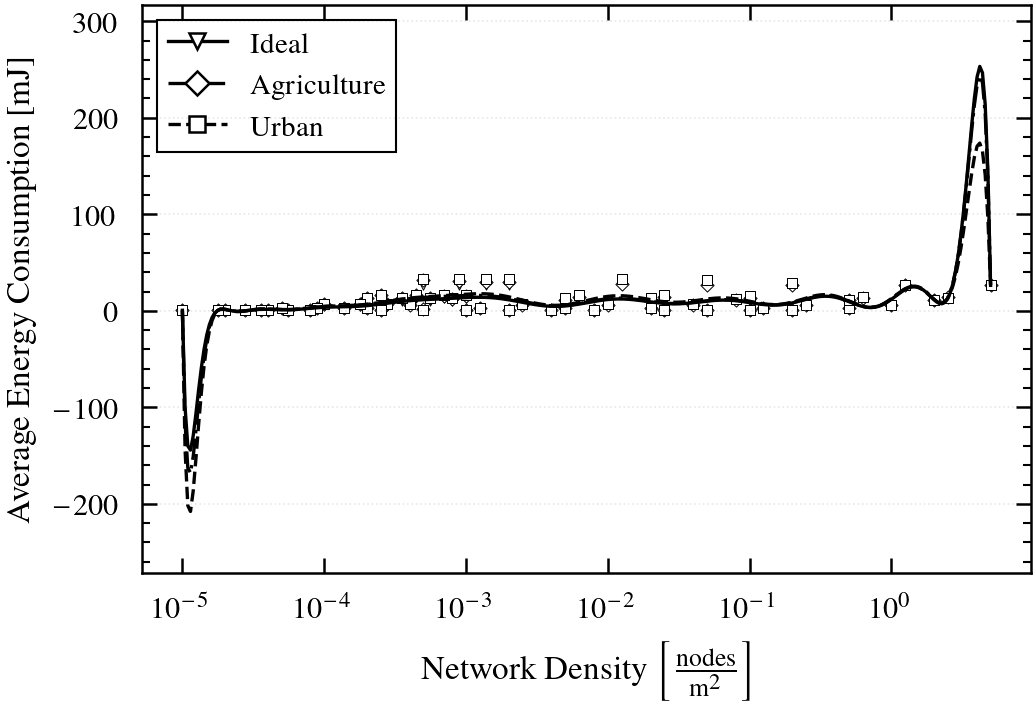

In [22]:
models = [
    ("Ideal",       "k", "-" , "v", "Ideal"),
    ("SUI_TypeC",   "k", "-.", "D", "Agriculture"),
    ("ITU_P1411",   "k", "--", "s", "Urban"),
]
legend_elements = []
metric = 'avg_energy_consumption'
degree = 25
fig, ax = plt.subplots(figsize=(3.5, 2.4), constrained_layout=True)


for model_name, color, linestyle, marker, label in models:
    densities = []
    values = []

    for (N, L), data in SINGLE_CHANNEL_CC2420_DATA[model_name].items():
        vals = data.get(metric, [])
        if len(vals) == 0:
            continue

        density = N / (L ** 2)
        densities.append(density)
        values.append(np.mean(vals))
    
    densities = np.array(densities)
    values = np.array(values)

    # sort from high density to low density
    idx = np.argsort(densities)[::-1]
    densities = densities[idx]
    values = values[idx]

    # Fit polynomial on log10(density)
    x_fit = np.log10(densities)
    p = np.poly1d(np.polyfit(x_fit, values, degree))

    x_smooth = np.linspace(x_fit.min(), x_fit.max(), 300)
    y_smooth = p(x_smooth)
    density_smooth = 10 ** x_smooth


    ax.scatter(
        densities,
        values,
        s=5,
        marker=marker,
        color=color,
        label=label,
        facecolor='w',
    )

    ax.plot(
        density_smooth,
        y_smooth,
        linestyle=linestyle,
        color=color,
        linewidth=0.8,
        markersize=4,
        markerfacecolor='white',
        markeredgewidth=0.6
    )

    ax.set_xscale('log')
    # ax.invert_xaxis()  # highest density on the left

        


    legend_elements.append(
        Line2D([0], [0], color=color, linestyle=linestyle, marker=marker, markerfacecolor='w',
           label=label)
    )

# Labels
ax.set_xlabel(r"Network Density $\left[\frac{\mathrm{nodes}}{\mathrm{m}^2}\right]$")
ax.set_ylabel('Average Energy Consumption [mJ]', fontsize=8, labelpad=4)

ax.tick_params(labelsize=7)

ax.grid(False)


ax.legend(
    handles=legend_elements,
    frameon=True,
    fontsize=7,
    edgecolor='black',
    facecolor='none'
)
apply_pgfplots_style(
    ax,
    # xlim=(0, 52),
    y_pad=0.08
)
plt.savefig(
    "/mnt/Program/All/Routing-Protocols/_docs/Paper 2026/MSWiM/assets/cc2420_energy_vs_network_density.png",
    bbox_inches="tight",
    dpi=600
)


## 4) PDR vs Network Density

<>:83: SyntaxWarning: invalid escape sequence '\%'
<>:83: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_190159/1390423035.py:83: SyntaxWarning: invalid escape sequence '\%'
  ax.set_ylabel('PDR [\%]', fontsize=8, labelpad=4)
/tmp/ipykernel_190159/1390423035.py:102: UserWarning: AutoMinorLocator does not work on logarithmic scales
  plt.savefig(


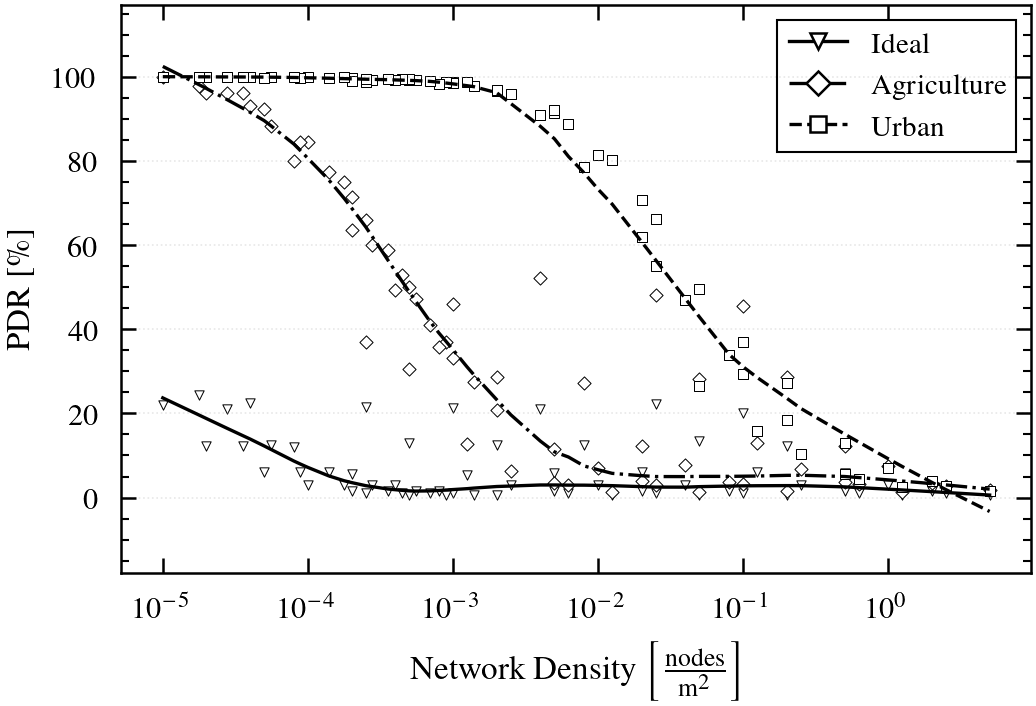

In [23]:
models = [
    ("Ideal",       "k", "-" , "v", "Ideal"),
    ("SUI_TypeC",   "k", "-.", "D", "Agriculture"),
    ("ITU_P1411",   "k", "--", "s", "Urban"),
]
legend_elements = []

metric = 'pdr'
fig, ax = plt.subplots(figsize=(3.5, 2.4), constrained_layout=True)


for model_name, color, linestyle, marker, label in models:
    densities = []
    values = []

    for (N, L), data in SINGLE_CHANNEL_CC2420_DATA[model_name].items():
        vals = data.get(metric, [])
        if len(vals) == 0:
            continue

        density = N / (L ** 2)
        densities.append(density)
        values.append(np.mean(vals))
    
    densities = np.array(densities)
    values = np.array(values)

    # sort from high density to low density
    idx = np.argsort(densities)[::-1]
    densities = densities[idx]
    values = values[idx]

    x = np.log10(densities)
    y = values

    smoothed = lowess(
        y,
        x,
        frac=0.3,      # smoothing factor
        return_sorted=True
    )

    x_smooth = smoothed[:,0]
    y_smooth = smoothed[:,1]

    density_smooth = 10**x_smooth


    ax.scatter(
        densities,
        values,
        s=5,
        marker=marker,
        color=color,
        label=label,
        facecolor='w',
    )

    ax.plot(
        density_smooth,
        y_smooth,
        linestyle=linestyle,
        color=color,
        linewidth=0.8,
        markersize=4,
        markerfacecolor='white',
        markeredgewidth=0.6
    )

    ax.set_xscale('log')
    # ax.invert_xaxis()  # highest density on the left

        


    legend_elements.append(
        Line2D([0], [0], color=color, linestyle=linestyle, marker=marker, markerfacecolor='w',
           label=label)
    )

# Labels
ax.set_xlabel(r"Network Density $\left[\frac{\mathrm{nodes}}{\mathrm{m}^2}\right]$")
ax.set_ylabel('PDR [\%]', fontsize=8, labelpad=4)

ax.tick_params(labelsize=7)

ax.grid(False)


ax.legend(
    handles=legend_elements,
    frameon=True,
    fontsize=7,
    edgecolor='black',
    facecolor='none'
)
apply_pgfplots_style(
    ax,
    # xlim=(0, 52),
    y_pad=0.08
)
plt.savefig(
    "/mnt/Program/All/Routing-Protocols/_docs/Paper 2026/MSWiM/assets/cc2420_pdr_vs_network_density.png",
    bbox_inches="tight",
    dpi=600
)


## 5) Hidden Node Detected vs Network Density

/tmp/ipykernel_190159/1603956523.py:121: UserWarning: AutoMinorLocator does not work on logarithmic scales
  plt.savefig(


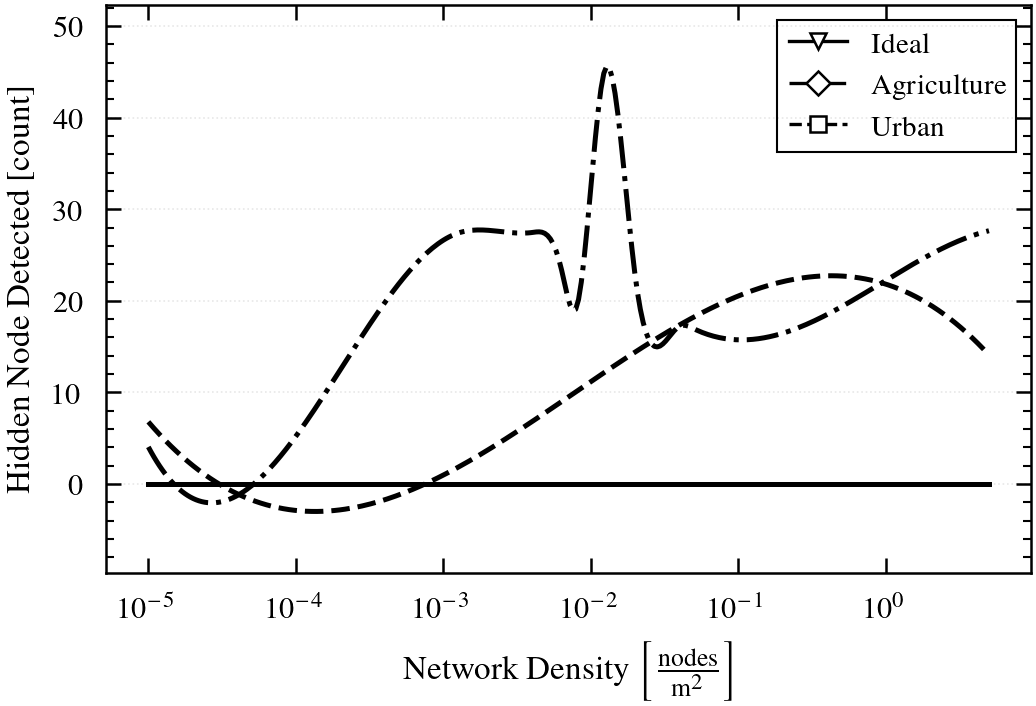

In [24]:
models = [
    ("Ideal",       "k", "-" , "v", "Ideal"),
    ("SUI_TypeC",   "k", "-.", "D", "Agriculture"),
    ("ITU_P1411",   "k", "--", "s", "Urban"),
]
legend_elements = []
metric = 'hidden_node_detected'
degree = 25
fig, ax = plt.subplots(figsize=(3.5, 2.4), constrained_layout=True)


for model_name, color, linestyle, marker, label in models:
    densities = []
    values = []

    for (N, L), data in SINGLE_CHANNEL_CC2420_DATA[model_name].items():
        vals = data.get(metric, [])
        if len(vals) == 0:
            continue

        density = N / (L ** 2)
        densities.append(density)
        values.append(np.mean(vals))
    
    densities = np.array(densities)
    values = np.array(values)

    # sort from high density to low density
    idx = np.argsort(densities)[::-1]
    densities = densities[idx]
    values = values[idx]

    # Fit polynomial on log10(density)
    x = np.log10(densities)
    y = values

    smoothed = lowess(
        y,
        x,
        frac=0.3,      # smoothing factor
        return_sorted=True
    )

    x_smooth = smoothed[:,0]
    y_smooth = smoothed[:,1]

    density_smooth = 10**x_smooth

    
    x_unique, inv = np.unique(x, return_inverse=True)
    y_unique = np.array([y[inv == i].mean() for i in range(len(x_unique))])

    # fit spline
    spline = UnivariateSpline(
        x_unique,
        y_unique,
        s=len(x_unique) * 50
    )

    # dense curve
    x_dense = np.linspace(x_unique.min(), x_unique.max(), 300)
    y_dense = spline(x_dense)
    density_dense = 10 ** x_dense
    ax.plot(density_dense, y_dense, linestyle=linestyle, color=color, linewidth=1.2)

    # ax.scatter(
    #     densities,
    #     values,
    #     s=5,
    #     marker=marker,
    #     color=color,
    #     label=label,
    #     facecolor='w',
    # )

    # ax.plot(
    #     density_smooth,
    #     y_smooth,
    #     linestyle=linestyle,
    #     color=color,
    #     linewidth=0.8,
    #     markersize=4,
    #     markerfacecolor='white',
    #     markeredgewidth=0.6
    # )

    

    ax.set_xscale('log')
    # ax.invert_xaxis()  # highest density on the left

        


    legend_elements.append(
        Line2D([0], [0], color=color, linestyle=linestyle, marker=marker, markerfacecolor='w',
           label=label)
    )

# Labels
ax.set_xlabel(r"Network Density $\left[\frac{\mathrm{nodes}}{\mathrm{m}^2}\right]$")
ax.set_ylabel('Hidden Node Detected [count]', fontsize=8, labelpad=4)

ax.tick_params(labelsize=7)

ax.grid(False)


ax.legend(
    handles=legend_elements,
    frameon=True,
    fontsize=7,
    edgecolor='black',
    facecolor='none'
)
apply_pgfplots_style(
    ax,
    # xlim=(0, 52),
    y_pad=0.08
)
plt.savefig(
    "/mnt/Program/All/Routing-Protocols/_docs/Paper 2026/MSWiM/assets/cc2420_hidden_node_detected_vs_network_density.png",
    bbox_inches="tight",
    dpi=600
)


## 6) Collision Failure vs Network Density

/tmp/ipykernel_190159/1288560358.py:117: UserWarning: AutoMinorLocator does not work on logarithmic scales
  plt.savefig(


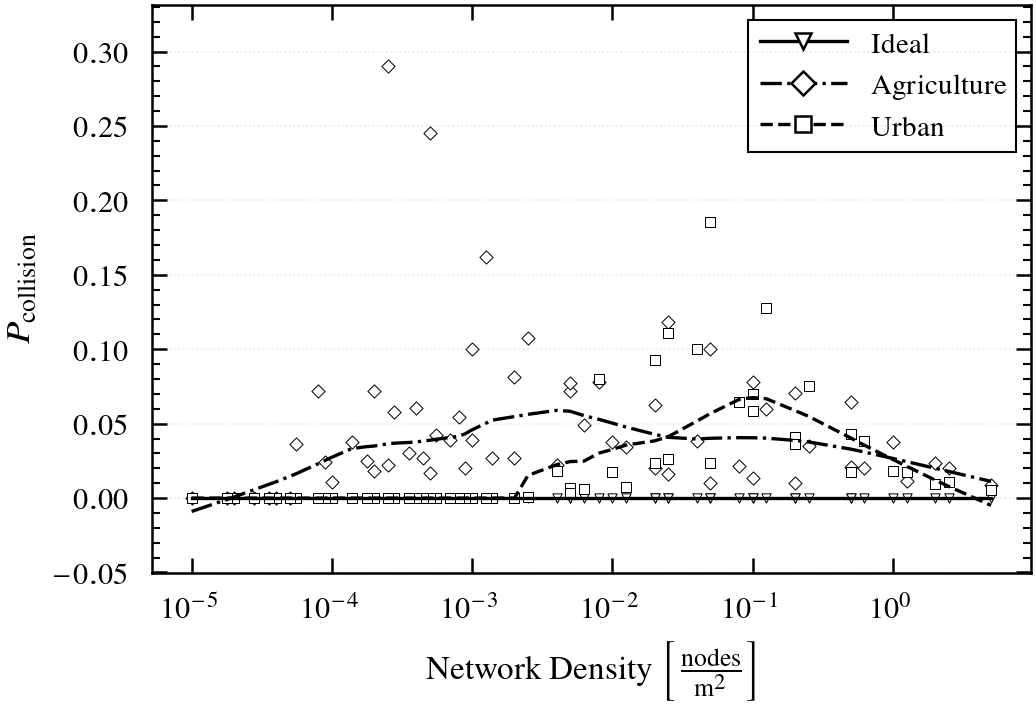

In [25]:
models = [
    ("Ideal",       "k", "-" , "v", "Ideal"),
    ("SUI_TypeC",   "k", "-.", "D", "Agriculture"),
    ("ITU_P1411",   "k", "--", "s", "Urban"),
]
legend_elements = []
metric = 'collision_failure'
degree = 25
fig, ax = plt.subplots(figsize=(3.5, 2.4), constrained_layout=True)

L_FIXED = 10

for model_name, color, linestyle, marker, label in models:
    densities = []
    values = []

    for (N, L), data in SINGLE_CHANNEL_CC2420_DATA[model_name].items():
        # if L == L_FIXED:
        #     vals = data.get(metric, [])
        #     if len(vals) == 0:
        #         continue

        #     density = N / (L ** 2)
        #     densities.append(density)
        #     values.append(np.mean(vals)/N)

        vals = data.get(metric, [])
        if len(vals) == 0:
            continue

        density = N / (L ** 2)
        densities.append(density)
        values.append(np.mean(vals)/N)

    densities = np.array(densities)
    values = np.array(values)

    # sort from high density to low density
    idx = np.argsort(densities)[::-1]
    densities = densities[idx]
    values = values[idx]

    # Fit polynomial on log10(density)
    x = np.log10(densities)
    y = values

    smoothed = lowess(
        y,
        x,
        frac=0.3,      # smoothing factor
        return_sorted=True
    )

    x_smooth = smoothed[:,0]
    y_smooth = smoothed[:,1]

    density_smooth = 10**x_smooth


    ax.scatter(
        densities,
        values,
        s=5,
        marker=marker,
        color=color,
        label=label,
        facecolor='w',
    )

    ax.plot(
        density_smooth,
        y_smooth,
        linestyle=linestyle,
        color=color,
        linewidth=0.8,
        markersize=4,
        markerfacecolor='white',
        markeredgewidth=0.6
    )

    ax.set_xscale('log')
    # ax.invert_xaxis()  # highest density on the left

        


    legend_elements.append(
        Line2D([0], [0], color=color, linestyle=linestyle, marker=marker, markerfacecolor='w',
           label=label)
    )

# Labels
# ax.set_ylim([0, 1])
ax.set_xlabel(r"Network Density $\left[\frac{\mathrm{nodes}}{\mathrm{m}^2}\right]$")
ax.set_ylabel('Hidden Node Detected [count]', fontsize=8, labelpad=4)
ax.set_ylabel(r"$P_{\mathrm{collision}}$", fontsize=8, labelpad=4)

ax.tick_params(labelsize=7)

ax.grid(False)


ax.legend(
    handles=legend_elements,
    frameon=True,
    fontsize=7,
    edgecolor='black',
    facecolor='none',
    handlelength=3.0,

)
apply_pgfplots_style(
    ax,
    # xlim=(0, 52),
    y_pad=0.08
)
plt.savefig(
    "/mnt/Program/All/Routing-Protocols/_docs/Paper 2026/MSWiM/assets/cc2420_collision_probabilities_vs_network_density.png",
    bbox_inches="tight",
    dpi=600
)


## 7) Channel Busy Failure vs Network Density

/tmp/ipykernel_190159/3155382516.py:115: UserWarning: AutoMinorLocator does not work on logarithmic scales
  plt.savefig(


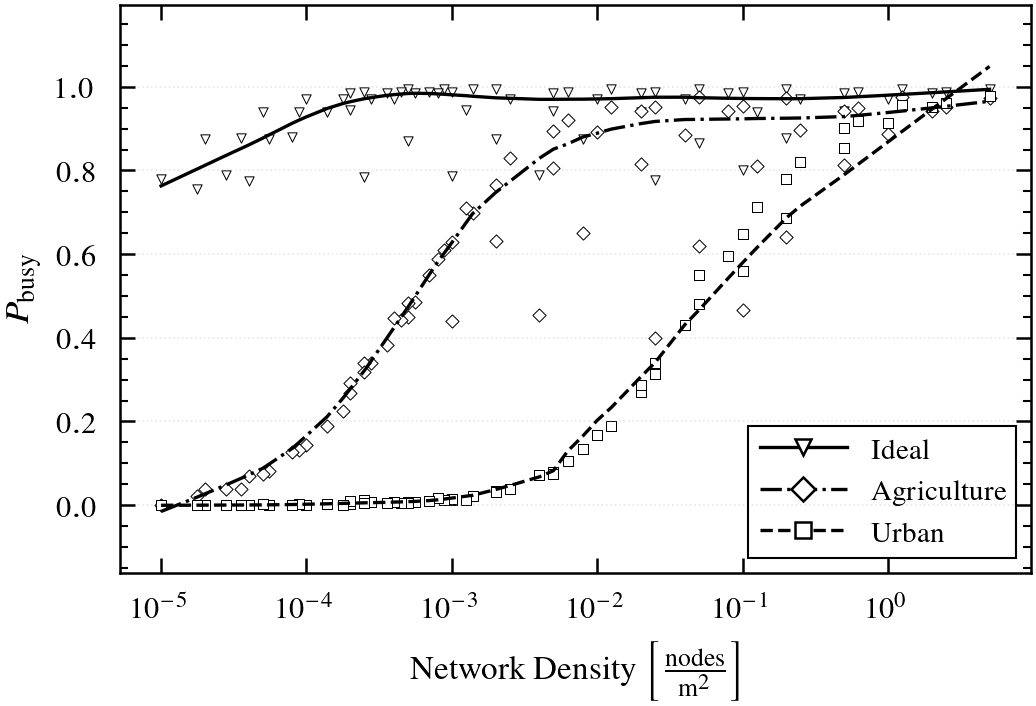

In [26]:
models = [
    ("Ideal",       "k", "-" , "v", "Ideal"),
    ("SUI_TypeC",   "k", "-.", "D", "Agriculture"),
    ("ITU_P1411",   "k", "--", "s", "Urban"),
]
legend_elements = []
metric = 'channel_busy_failure'
degree = 25
fig, ax = plt.subplots(figsize=(3.5, 2.4), constrained_layout=True)

L_FIXED = 200

for model_name, color, linestyle, marker, label in models:
    densities = []
    values = []

    for (N, L), data in SINGLE_CHANNEL_CC2420_DATA[model_name].items():
        # if L == L_FIXED:
        #     vals = data.get(metric, [])
        #     if len(vals) == 0:
        #         continue

        #     density = N / (L ** 2)
        #     densities.append(density)
        #     values.append(np.mean(vals))

        vals = data.get(metric, [])
        if len(vals) == 0:
            continue

        density = N / (L ** 2)
        densities.append(density)
        values.append(np.mean(vals)/N)

    densities = np.array(densities)
    values = np.array(values)

    # sort from high density to low density
    idx = np.argsort(densities)[::-1]
    densities = densities[idx]
    values = values[idx]

    # Fit polynomial on log10(density)
    x = np.log10(densities)
    y = values

    smoothed = lowess(
        y,
        x,
        frac=0.3,      # smoothing factor
        return_sorted=True
    )

    x_smooth = smoothed[:,0]
    y_smooth = smoothed[:,1]

    density_smooth = 10**x_smooth


    ax.scatter(
        densities,
        values,
        s=5,
        marker=marker,
        color=color,
        label=label,
        facecolor='w',
    )

    ax.plot(
        density_smooth,
        y_smooth,
        linestyle=linestyle,
        color=color,
        linewidth=0.8,
        markersize=4,
        markerfacecolor='white',
        markeredgewidth=0.6
    )

    ax.set_xscale('log')
    # ax.invert_xaxis()  # highest density on the left

        


    legend_elements.append(
        Line2D([0], [0], color=color, linestyle=linestyle, marker=marker, markerfacecolor='w',
           label=label)
    )

# Labels
ax.set_xlabel(r"Network Density $\left[\frac{\mathrm{nodes}}{\mathrm{m}^2}\right]$")
ax.set_ylabel('Channel Busy [count]', fontsize=8, labelpad=4)
ax.set_ylabel(r"$P_{\mathrm{busy}}$", fontsize=8, labelpad=4)
ax.tick_params(labelsize=7)

ax.grid(False)


ax.legend(
    handles=legend_elements,
    frameon=True,
    fontsize=7,
    edgecolor='black',
    handlelength=3.0,
    facecolor='none'
)

apply_pgfplots_style(
    ax,
    # xlim=(0, 52),
    y_pad=0.08
)
plt.savefig(
    "/mnt/Program/All/Routing-Protocols/_docs/Paper 2026/MSWiM/assets/cc2420_channel_Busy_vs_network_density.png",
    bbox_inches="tight",
    dpi=600
)


## Hidden Node Contour

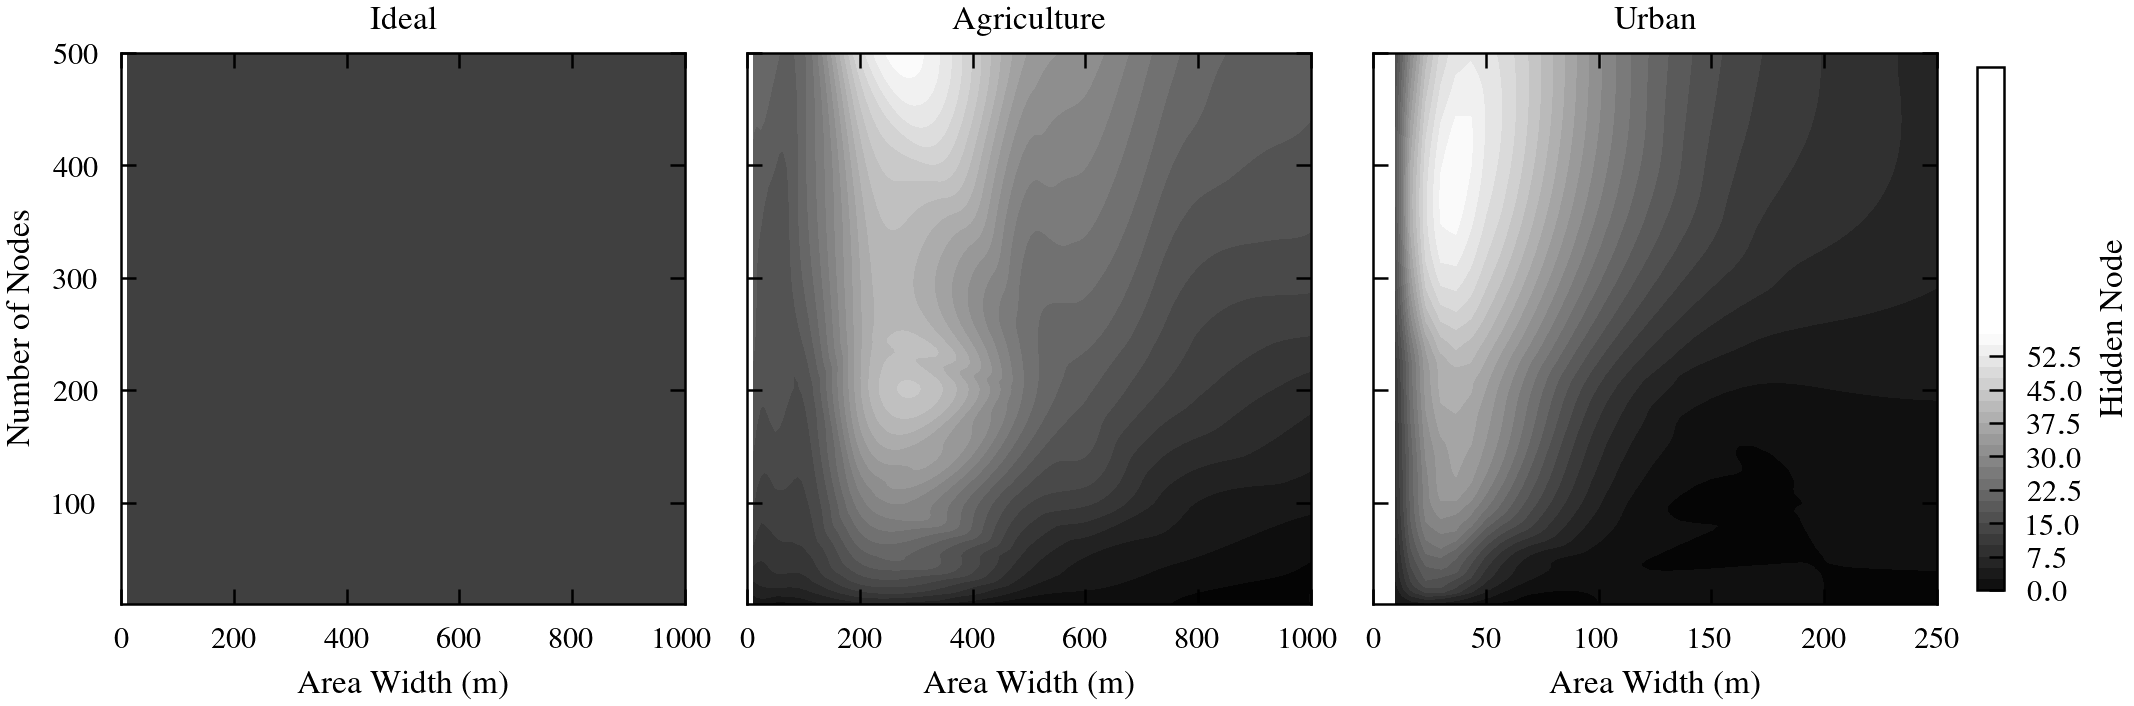

In [27]:
fig, axes = plt.subplots(
    1, 3,
    figsize=(7.16, 2.4),   # IEEE double-column width
    sharey=True,
    constrained_layout=True
)

models = [
    ("Ideal", "Ideal"),
    ("SUI_TypeC", "Agriculture"),
    ("ITU_P1411", "Urban"),
]

threshold = 75

for idx, (ax, (key, title)) in enumerate(zip(axes, models)):


    X, Y, Z, L_values, N_values = build_grids(
        SINGLE_CHANNEL_CC2420_DATA[key],
        metric='hidden_node_detected'
    )

    L_fine = np.linspace(min(L_values), max(L_values), 150)
    N_fine = np.linspace(min(N_values), max(N_values), 150)

    L_grid, N_grid = np.meshgrid(
        L_fine,
        N_fine
    )

    Z_fine = griddata(
        np.column_stack((X.ravel(), Y.ravel())),
        Z.ravel(),
        (L_grid, N_grid),
        method='cubic'
    )

    # Main contour map
    cf = ax.contourf(
        L_grid,
        N_grid,
        Z_fine,
        levels=25,
        cmap='binary_r'
    )

    # Iso-PDR line
    ax.contour(
        L_grid,
        N_grid,
        Z_fine,
        levels=[threshold],
        colors='black',
        linewidths=1.5
    )

    # Region satisfying requirement
    ax.contourf(
        L_grid,
        N_grid,
        Z_fine,
        levels=[threshold, 100],
        colors='none',
        hatches=['///']
    )

    # Original simulation points
    # ax.scatter(
    #     X,
    #     Y,
    #     s=8,
    #     c='k',
    #     alpha=0.4
    # )

    ax.set_title(title, fontsize=8)

    ax.tick_params(
        labelsize=7,
        direction='in'
    )

    if idx == 2:

        # axins = zoomed_inset_axes(
        #     ax,
        #     zoom=2.5,
        #     loc='upper left'
        # )

        # # redraw contour on inset
        # axins.contourf(
        #     L_grid,
        #     N_grid,
        #     Z_fine,
        #     levels=25,
        #     cmap='binary_r'
        # )

        # axins.contour(
        #     L_grid,
        #     N_grid,
        #     Z_fine,
        #     levels=[threshold],
        #     colors='black',
        #     linewidths=1.0
        # )

        # axins.contourf(
        #     L_grid,
        #     N_grid,
        #     Z_fine,
        #     levels=[threshold, 100],
        #     colors='none',
        #     hatches=['///']
        # )

        # axins.scatter(
        #     X,
        #     Y,
        #     s=5,
        #     c='k',
        #     alpha=0.3
        # )

        # # Region to zoom
        # N1, N2 = 10, 50
        # L1, L2 = 450, 500

        # axins.set_xlim(L1, L2)
        # axins.set_ylim(N1, N2)

        # axins.set_xticks([])
        # axins.set_yticks([])

        # mark_inset(
        #     ax,
        #     axins,
        #     loc1=3,
        #     loc2=1,
        #     fc="none",
        #     ec="black",
        #     color='w',
        #     lw=0.8
        # )
        L1, L2 = 0, 250
        ax.set_xlim(L1, L2)

        # N1, N2 = 10, 50
        # ax.set_ylim(N1, N2)
    else:
        L1, L2 = 0, 1000
        ax.set_xlim(L1, L2)

axes[0].set_ylabel(
    "Number of Nodes",
    fontsize=8
)

for ax in axes:
    ax.set_xlabel(
        "Area Width (m)",
        fontsize=8
    )

cbar = fig.colorbar(
    cf,
    ax=axes,
    pad=0.01,
    shrink=0.95
)

cbar.set_label(
    "Hidden Node",
    fontsize=8
)
cbar.ax.set_ylim(bottom=0, top=60) 
cbar.ax.tick_params(labelsize=7)

plt.savefig(
    "/mnt/Program/All/Routing-Protocols/_docs/Paper 2026/MSWiM/assets/cc2420_hidden_node_detected_operational_regions.png",
    bbox_inches="tight",
    dpi=600
)
plt.show()

# ESP32-C6 vs CC2420

## PDR

<>:84: SyntaxWarning: invalid escape sequence '\%'
<>:84: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_190159/2043080094.py:84: SyntaxWarning: invalid escape sequence '\%'
  ax.set_ylabel('PDR [\%]', fontsize=8, labelpad=4)
/tmp/ipykernel_190159/2043080094.py:103: UserWarning: AutoMinorLocator does not work on logarithmic scales
  plt.savefig(


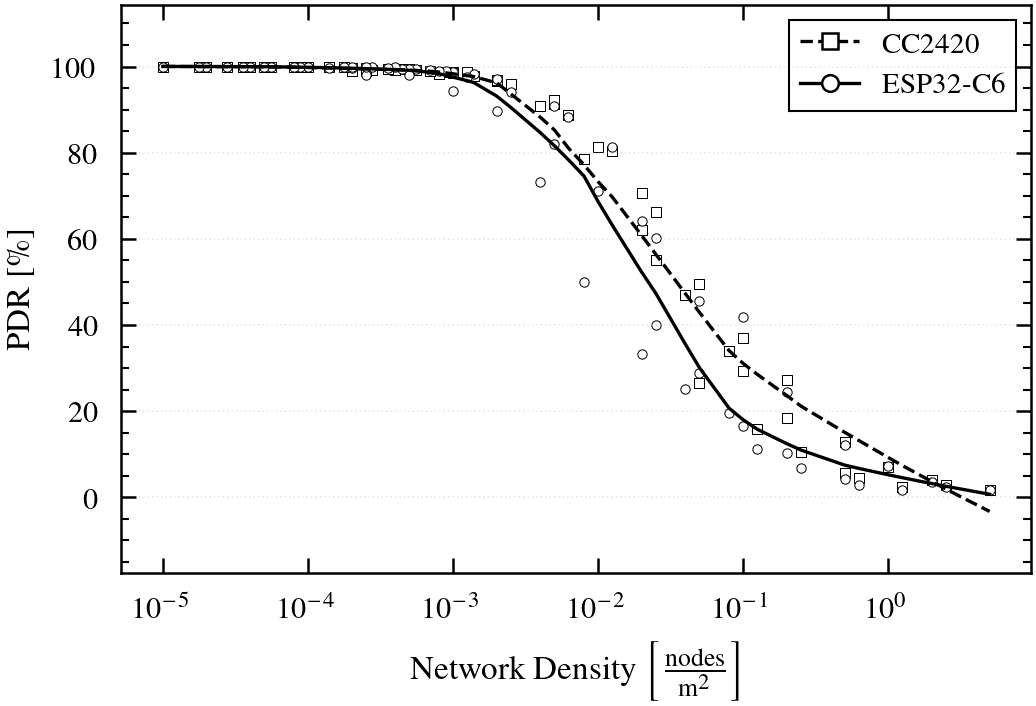

In [28]:
models = [
    (SINGLE_CHANNEL_CC2420_DATA     , "ITU_P1411",   "k", "--", "s", "CC2420"),
    (SINGLE_CHANNEL_ESP32_C6_DATA   , "ITU_P1411",   "k", "solid", "o", "ESP32-C6"),
]
legend_elements = []
metric = 'pdr'
degree = 25
fig, ax = plt.subplots(figsize=(3.5, 2.4), constrained_layout=True)


for result, model_name, color, linestyle, marker, label in models:
    densities = []
    values = []

    for (N, L), data in result[model_name].items():
        vals = data.get(metric, [])
        if len(vals) == 0:
            continue

        density = N / (L ** 2)
        densities.append(density)
        values.append(np.mean(vals))
    
    densities = np.array(densities)
    values = np.array(values)

    # sort from high density to low density
    idx = np.argsort(densities)[::-1]
    densities = densities[idx]
    values = values[idx]

    # Fit polynomial on log10(density)
    
    x = np.log10(densities)
    y = values

    smoothed = lowess(
        y,
        x,
        frac=0.3,      # smoothing factor
        return_sorted=True
    )

    x_smooth = smoothed[:,0]
    y_smooth = smoothed[:,1]

    density_smooth = 10**x_smooth


    ax.scatter(
        densities,
        values,
        s=5,
        marker=marker,
        color=color,
        label=label,
        facecolor='w',
    )

    ax.plot(
        density_smooth,
        y_smooth,
        linestyle=linestyle,
        color=color,
        linewidth=0.8,
        markersize=4,
        markerfacecolor='white',
        markeredgewidth=0.6
    )

    ax.set_xscale('log')
    # ax.invert_xaxis()  # highest density on the left

        


    legend_elements.append(
        Line2D([0], [0], color=color, linestyle=linestyle, marker=marker, markerfacecolor='w',
           label=label)
    )

# Labels
ax.set_xlabel(r"Network Density $\left[\frac{\mathrm{nodes}}{\mathrm{m}^2}\right]$")
ax.set_ylabel('PDR [\%]', fontsize=8, labelpad=4)

ax.tick_params(labelsize=7)

ax.grid(False)


ax.legend(
    handles=legend_elements,
    frameon=True,
    fontsize=7,
    edgecolor='black',
    facecolor='none'
)
apply_pgfplots_style(
    ax,
    # xlim=(0, 52),
    y_pad=0.08
)
plt.savefig(
    "/mnt/Program/All/Routing-Protocols/_docs/Paper 2026/MSWiM/assets/cc2420_vs_esp32_cc6_pdr_vs_network_density.png",
    bbox_inches="tight",
    dpi=600
)


# Collision Failure vs Network Densities

/tmp/ipykernel_190159/616112721.py:103: UserWarning: AutoMinorLocator does not work on logarithmic scales
  plt.savefig(


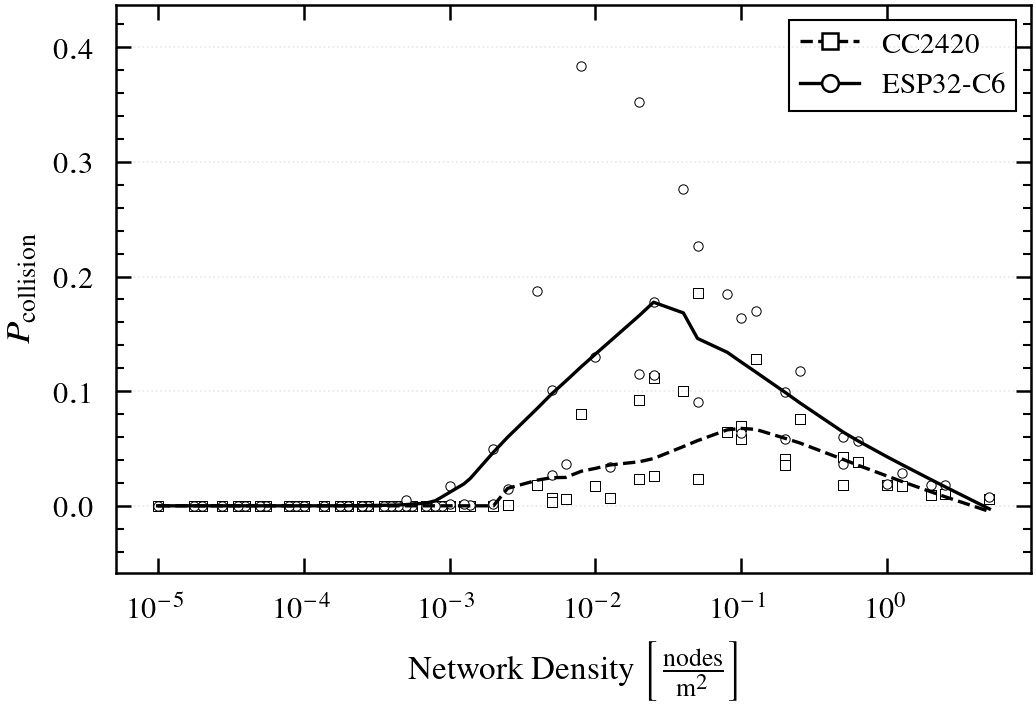

In [29]:
models = [
    (SINGLE_CHANNEL_CC2420_DATA     , "ITU_P1411",   "k", "--", "s", "CC2420"),
    (SINGLE_CHANNEL_ESP32_C6_DATA   , "ITU_P1411",   "k", "solid", "o", "ESP32-C6"),
]
legend_elements = []
metric = 'collision_failure'
degree = 25
fig, ax = plt.subplots(figsize=(3.5, 2.4), constrained_layout=True)


for result, model_name, color, linestyle, marker, label in models:
    densities = []
    values = []

    for (N, L), data in result[model_name].items():
        vals = data.get(metric, [])
        if len(vals) == 0:
            continue

        density = N / (L ** 2)
        densities.append(density)
        values.append(np.mean(vals)/N)
    
    densities = np.array(densities)
    values = np.array(values)

    # sort from high density to low density
    idx = np.argsort(densities)[::-1]
    densities = densities[idx]
    values = values[idx]

    # Fit polynomial on log10(density)
    
    x = np.log10(densities)
    y = values

    smoothed = lowess(
        y,
        x,
        frac=0.3,      # smoothing factor
        return_sorted=True
    )

    x_smooth = smoothed[:,0]
    y_smooth = smoothed[:,1]

    density_smooth = 10**x_smooth


    ax.scatter(
        densities,
        values,
        s=5,
        marker=marker,
        color=color,
        label=label,
        facecolor='w',
    )

    ax.plot(
        density_smooth,
        y_smooth,
        linestyle=linestyle,
        color=color,
        linewidth=0.8,
        markersize=4,
        markerfacecolor='white',
        markeredgewidth=0.6
    )

    ax.set_xscale('log')
    # ax.invert_xaxis()  # highest density on the left

        


    legend_elements.append(
        Line2D([0], [0], color=color, linestyle=linestyle, marker=marker, markerfacecolor='w',
           label=label)
    )

# Labels
ax.set_xlabel(r"Network Density $\left[\frac{\mathrm{nodes}}{\mathrm{m}^2}\right]$")
ax.set_ylabel(r"$P_{\mathrm{collision}}$", fontsize=8, labelpad=4)

ax.tick_params(labelsize=7)

ax.grid(False)


ax.legend(
    handles=legend_elements,
    frameon=True,
    fontsize=7,
    edgecolor='black',
    facecolor='none'
)
apply_pgfplots_style(
    ax,
    # xlim=(0, 52),
    y_pad=0.08
)
plt.savefig(
    "/mnt/Program/All/Routing-Protocols/_docs/Paper 2026/MSWiM/assets/cc2420_vs_esp32_cc6_collision_failures_vs_network_density.png",
    bbox_inches="tight",
    dpi=600
)


## Energy Consumption

/tmp/ipykernel_190159/2091521312.py:114: UserWarning: AutoMinorLocator does not work on logarithmic scales
  plt.savefig(


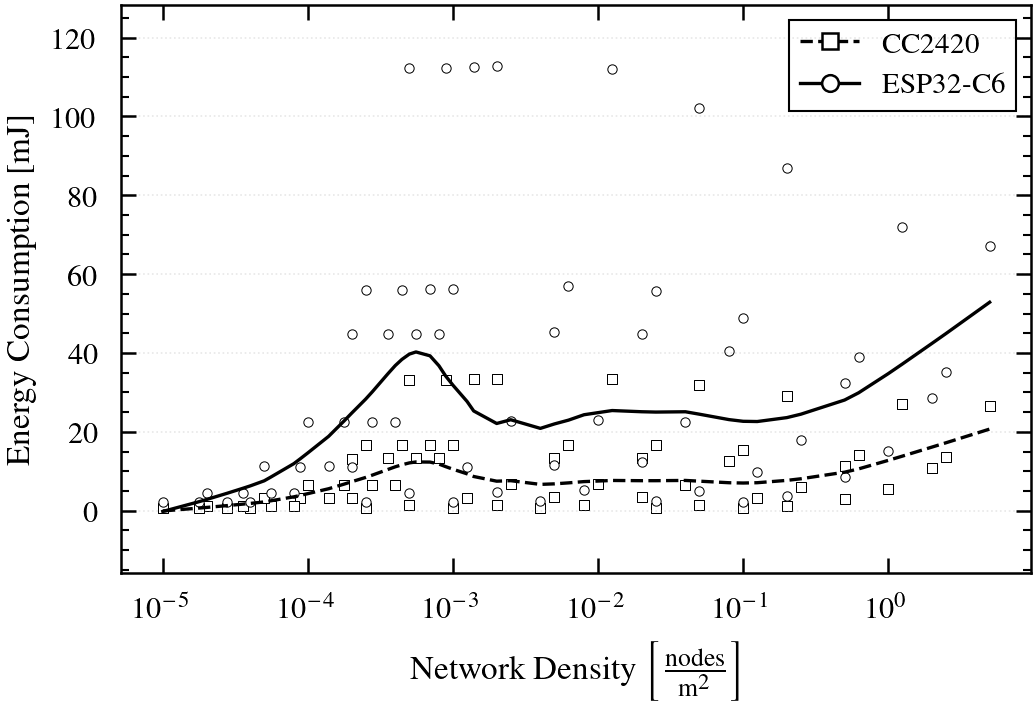

In [30]:
models = [
    (SINGLE_CHANNEL_CC2420_DATA     , "ITU_P1411",   "k", "--", "s", "CC2420"),
    (SINGLE_CHANNEL_ESP32_C6_DATA   , "ITU_P1411",   "k", "solid", "o", "ESP32-C6"),
]
legend_elements = []
metric = 'avg_energy_consumption'
degree = 25
fig, ax = plt.subplots(figsize=(3.5, 2.4), constrained_layout=True)


for result, model_name, color, linestyle, marker, label in models:
    densities = []
    values = []

    for (N, L), data in result[model_name].items():
        vals = data.get(metric, [])
        if len(vals) == 0:
            continue

        density = N / (L ** 2)
        densities.append(density)
        values.append(np.mean(vals))
    
    densities = np.array(densities)
    values = np.array(values)

    # sort from high density to low density
    idx = np.argsort(densities)[::-1]
    densities = densities[idx]
    values = values[idx]

    # Fit polynomial on log10(density)
    
    x = np.log10(densities)
    y = values

    smoothed = lowess(
        y,
        x,
        frac=0.3,      # smoothing factor
        return_sorted=True
    )

    x_smooth = smoothed[:,0]
    y_smooth = smoothed[:,1]

    density_smooth = 10**x_smooth


    ax.scatter(
        densities,
        values,
        s=5,
        marker=marker,
        color=color,
        label=label,
        facecolor='w',
    )

    ax.plot(
        density_smooth,
        y_smooth,
        linestyle=linestyle,
        color=color,
        linewidth=0.8,
        markersize=4,
        markerfacecolor='white',
        markeredgewidth=0.6
    )

    # ax.plot(
    #     values,
    #     densities,
    #     linestyle=linestyle,
    #     marker=marker,
    #     color=color,
    #     markersize=4,
    #     markerfacecolor='white',
    #     markeredgewidth=0.6
    # )

    ax.set_xscale('log')
    # ax.invert_xaxis()  # highest density on the left

        


    legend_elements.append(
        Line2D([0], [0], color=color, linestyle=linestyle, marker=marker, markerfacecolor='w',
           label=label)
    )

# Labels
ax.set_xlabel(r"Network Density $\left[\frac{\mathrm{nodes}}{\mathrm{m}^2}\right]$")
ax.set_ylabel('Energy Consumption [mJ]', fontsize=8, labelpad=4)

ax.tick_params(labelsize=7)

ax.grid(False)


ax.legend(
    handles=legend_elements,
    frameon=True,
    fontsize=7,
    edgecolor='black',
    facecolor='none'
)
apply_pgfplots_style(
    ax,
    # xlim=(0, 52),
    y_pad=0.08
)
plt.savefig(
    "/mnt/Program/All/Routing-Protocols/_docs/Paper 2026/MSWiM/assets/cc2420_vs_esp32_c6_average_energy_consumption.png",
    bbox_inches="tight",
    dpi=600
)


# Latency

/tmp/ipykernel_190159/278505017.py:114: UserWarning: AutoMinorLocator does not work on logarithmic scales
  plt.savefig(


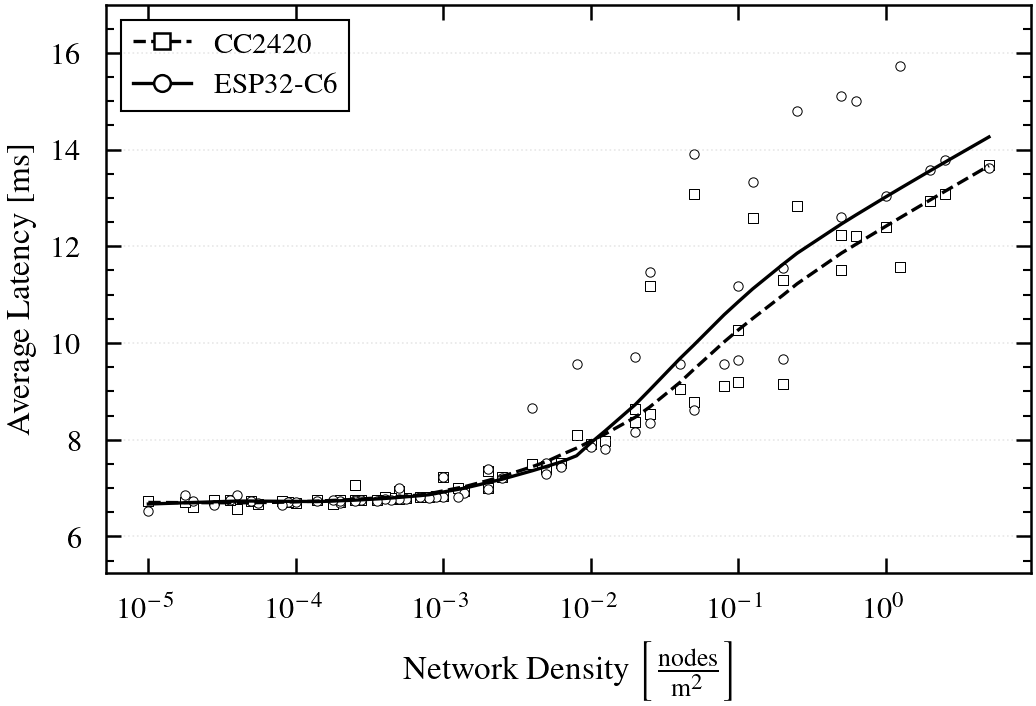

In [31]:
models = [
    (SINGLE_CHANNEL_CC2420_DATA     , "ITU_P1411",   "k", "--", "s", "CC2420"),
    (SINGLE_CHANNEL_ESP32_C6_DATA   , "ITU_P1411",   "k", "solid", "o", "ESP32-C6"),
]
legend_elements = []
metric = 'avg_latency_ms'
degree = 25
fig, ax = plt.subplots(figsize=(3.5, 2.4), constrained_layout=True)


for result, model_name, color, linestyle, marker, label in models:
    densities = []
    values = []

    for (N, L), data in result[model_name].items():
        vals = data.get(metric, [])
        if len(vals) == 0:
            continue

        density = N / (L ** 2)
        densities.append(density)
        values.append(np.mean(vals))
    
    densities = np.array(densities)
    values = np.array(values)

    # sort from high density to low density
    idx = np.argsort(densities)[::-1]
    densities = densities[idx]
    values = values[idx]

    # Fit polynomial on log10(density)
    
    x = np.log10(densities)
    y = values

    smoothed = lowess(
        y,
        x,
        frac=0.3,      # smoothing factor
        return_sorted=True
    )

    x_smooth = smoothed[:,0]
    y_smooth = smoothed[:,1]

    density_smooth = 10**x_smooth


    ax.scatter(
        densities,
        values,
        s=5,
        marker=marker,
        color=color,
        label=label,
        facecolor='w',
    )

    ax.plot(
        density_smooth,
        y_smooth,
        linestyle=linestyle,
        color=color,
        linewidth=0.8,
        markersize=4,
        markerfacecolor='white',
        markeredgewidth=0.6
    )

    # ax.plot(
    #     values,
    #     densities,
    #     linestyle=linestyle,
    #     marker=marker,
    #     color=color,
    #     markersize=4,
    #     markerfacecolor='white',
    #     markeredgewidth=0.6
    # )

    ax.set_xscale('log')
    ax.invert_xaxis()  # highest density on the left

        


    legend_elements.append(
        Line2D([0], [0], color=color, linestyle=linestyle, marker=marker, markerfacecolor='w',
           label=label)
    )

# Labels
ax.set_xlabel(r"Network Density $\left[\frac{\mathrm{nodes}}{\mathrm{m}^2}\right]$")
ax.set_ylabel('Average Latency [ms]', fontsize=8, labelpad=4)

ax.tick_params(labelsize=7)

ax.grid(False)


ax.legend(
    handles=legend_elements,
    frameon=True,
    fontsize=7,
    edgecolor='black',
    facecolor='none'
)
apply_pgfplots_style(
    ax,
    # xlim=(0, 52),
    y_pad=0.08
)
plt.savefig(
    "/mnt/Program/All/Routing-Protocols/_docs/Paper 2026/MSWiM/assets/cc2420_vs_esp32_c6_average_energy_consumption.png",
    bbox_inches="tight",
    dpi=600
)


## Frontier Plot

<>:2: SyntaxWarning: invalid escape sequence '\%'
<>:2: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_190159/423041639.py:2: SyntaxWarning: invalid escape sequence '\%'
  x_label='PDR [\%]'
/tmp/ipykernel_190159/423041639.py:62: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(
/tmp/ipykernel_190159/423041639.py:62: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "-o" (-> marker='o'). The keyword argument will take precedence.
  ax.plot(


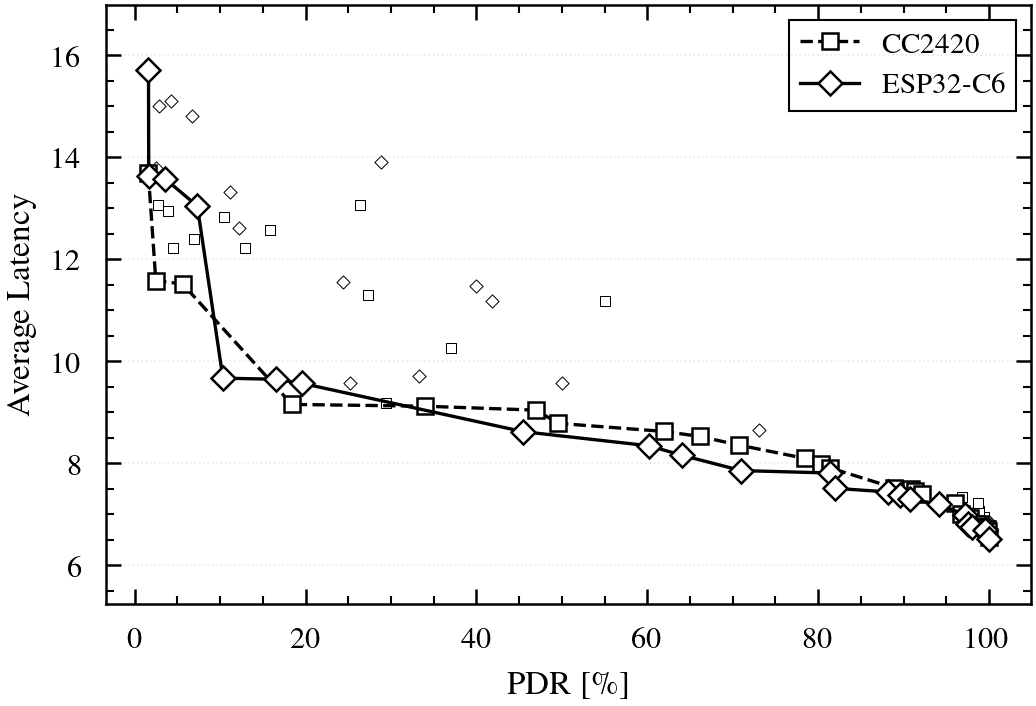

In [32]:
x_metric = 'pdr'
x_label='PDR [\%]'

y_metric = 'avg_latency_ms'
y_label='Average Latency'

models = [
    (SINGLE_CHANNEL_CC2420_DATA     , "ITU_P1411",   "k", "--", "s", "CC2420"),
    (SINGLE_CHANNEL_ESP32_C6_DATA   , "ITU_P1411",   "k", "solid", "D", "ESP32-C6"),
]
legend_elements = []
metric = 'pdr'
degree = 25
fig, ax = plt.subplots(figsize=(3.5, 2.4), constrained_layout=True)


for result, model_name, color, linestyle, marker, label in models:
    
    points = []
    for (N, L), data in result[model_name].items():
        x_vals = data.get(x_metric, [])
        y_vals = data.get(y_metric, [])

        if len(x_vals) == 0 or len(y_vals) == 0:
            continue

        x = np.mean(x_vals)
        y = np.mean(y_vals)

        if not np.isnan(x) and not np.isnan(y):
            points.append((x, y))

    if len(points) == 0:
        print(f"No valid data for Pareto plot: {x_metric} vs {y_metric}")

    points = np.array(points)
    frontier = get_pareto_frontier(points, minimize_x=True, maximize_y=False)


    # All points
    # ax.scatter(
    #     points[:, 0],
    #     points[:, 1],
    #     s=45,
    #     marker=marker,
    #     alpha=0.7,
    #     label="All configurations"
    # )

    ax.scatter(
        points[:, 0],
        points[:, 1],
        s=5,
        marker=marker,
        color=color,
        label=label,
        facecolor='w',
    )

    # Pareto frontier
    if len(frontier) > 0:
        ax.plot(
            frontier[:, 0],
            frontier[:, 1],
            '-o',
            color=color, 
            linestyle=linestyle, 
            marker=marker,
            markersize=4, markerfacecolor='white', markeredgewidth=0.6,
            linewidth=0.8, markevery=1,
            label="Pareto frontier"
        )
    legend_elements.append(
        Line2D([0], [0], color=color, linestyle=linestyle, marker=marker, markerfacecolor='w',
           label=label)
    )

ax.set_xlabel(x_label if x_label else x_metric)
ax.set_ylabel(y_label if y_label else y_metric)

ax.legend(
    handles=legend_elements,
    frameon=True,
    fontsize=7,
    edgecolor='black',
    facecolor='none'
)
apply_pgfplots_style(
    ax,
    # xlim=(0, 52),
    y_pad=0.08
)

plt.show()

In [33]:
frontier

array([[  1.61818182,  15.71776026],
       [  1.64615385,  13.62543794],
       [  3.55555556,  13.58034159],
       [  7.33333333,  13.04476379],
       [ 10.33333333,   9.66998022],
       [ 16.5       ,   9.64903291],
       [ 19.59090909,   9.56868547],
       [ 45.45714286,   8.6214517 ],
       [ 60.17777778,   8.34452074],
       [ 64.0625    ,   8.15774294],
       [ 71.        ,   7.85736672],
       [ 81.3375    ,   7.81075322],
       [ 82.        ,   7.50967165],
       [ 88.21818182,   7.43879331],
       [ 89.61538462,   7.3883786 ],
       [ 90.73076923,   7.29505249],
       [ 94.2       ,   7.20087693],
       [ 97.18095238,   6.98444638],
       [ 97.5       ,   6.8136907 ],
       [ 98.        ,   6.75175743],
       [ 99.55555556,   6.68734691],
       [100.        ,   6.51635875]])

# Move the Data

In [34]:
for folder in os.listdir('../output'):
    for key, path in SINGLE_CHANNEL_CC2420_PATHS.items():
        if key in folder:
            # print(f"{key} \t => {folder}")
            shutil.move(
                '../output' + "/" + folder,
                path + "/" + folder,

            )

In [35]:
for folder in os.listdir('../output'):
    for key, path in SINGLE_CHANNEL_ESP32_C6_PATHS.items():
        if key in folder:
            # print(f"{key} \t => {folder}")
            shutil.move(
                '../output' + "/" + folder,
                path + "/" + folder,

            )